# CS 5480: Deep Learning — Assignment 3
## Making Deep Networks Train Well

**Total: 100 points (+35 bonus)**  
**Due: April 16, 2026 at 11:59 PM**

---

### Instructions
- If you are not attempting the theory bonus question, this notebook is your **only submission file** — ZIP it as `LastName_FirstName_Assignment3.zip`. If you are also submitting the theory bonus, include both this notebook and your typeset PDF in the same ZIP file.
- Use **NumPy only** for all implementations — no PyTorch, TensorFlow, or any autograd library
- Run all cells **top-to-bottom** before submitting — no errors allowed
- Each Part ends with an **Analysis** markdown cell where you write your answers
- Set random seeds before every training run for reproducibility

### Dataset
This notebook uses **Fashion-MNIST** — 28×28 grayscale images of clothing items,
784-dimensional feature vectors, 10 classes, 70,000 samples (60k train / 10k test).

Classes: T-shirt, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot.

The dataset loads automatically in Google Colab via Keras (no manual download needed).


✓ Fashion-MNIST loaded via Keras

5-class subset — train: (24000, 784), test: (6000, 784)
Full 10-class  — train: (60000, 784), test: (10000, 784)


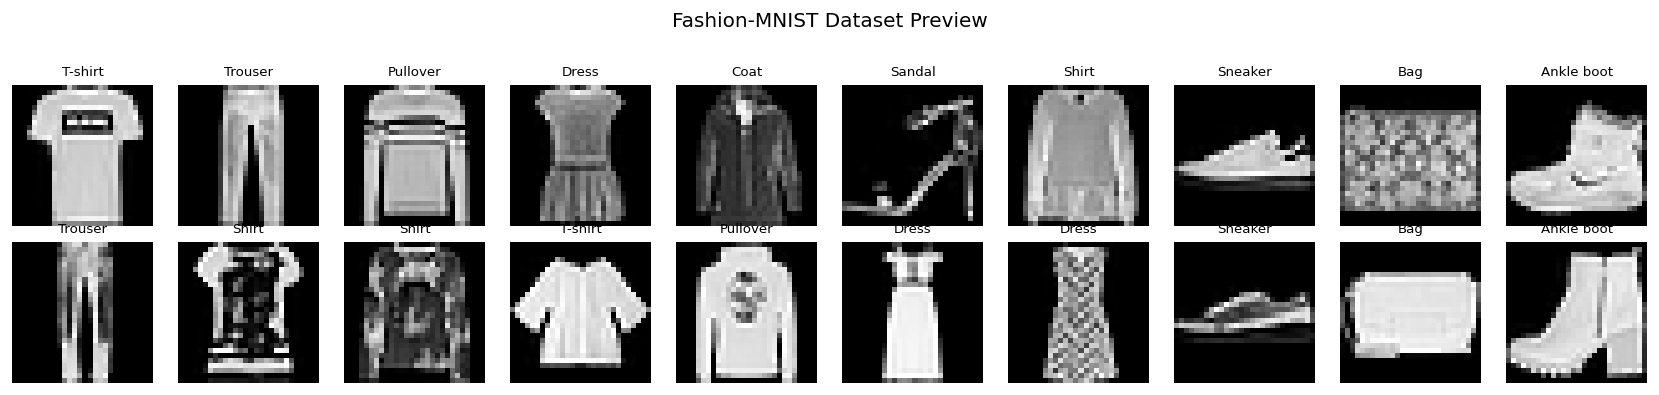

✓ Utilities loaded.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ── Colab / environment setup ─────────────────────────────────────────────────
try:
    from tensorflow.keras.datasets import fashion_mnist as fmnist
    (X_tr_raw, y_train_full), (X_te_raw, y_test_full) = fmnist.load_data()
    X_train_full = X_tr_raw.reshape(-1, 784).astype(np.float64) / 255.0
    X_test_full  = X_te_raw.reshape(-1, 784).astype(np.float64) / 255.0
    print("✓ Fashion-MNIST loaded via Keras")
except Exception as e:
    # Offline fallback — pads sklearn digits to 784 dims for local testing
    print(f"Keras unavailable ({e}), using offline fallback.")
    from sklearn.datasets import load_digits
    _d = load_digits()
    X_train_full = np.pad(_d.data.astype(np.float64)/16., ((0,0),(0,720)))
    X_test_full  = X_train_full.copy()
    y_train_full = _d.target.astype(int)
    y_test_full  = y_train_full.copy()
    print("  (Offline fallback active — results will differ from full Fashion-MNIST)")

CLASS_NAMES = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

# ─────────────────────────────────────────────────────────────────────────────
# DATASET LOADER
# ─────────────────────────────────────────────────────────────────────────────
def load_dataset(n_classes=10, n_train=None, n_test=None, seed=GLOBAL_SEED,
                 use_test_split=False):
    """
    Slice Fashion-MNIST to the requested number of classes and samples.
    use_test_split=True  → use the real 60k/10k split
    use_test_split=False → carve a stratified 80/20 split from the training set
                           (used in Parts 1-4 so all experiments are comparable)
    """
    if use_test_split:
        mask_tr = y_train_full < n_classes
        mask_te = y_test_full  < n_classes
        X_tr, y_tr = X_train_full[mask_tr], y_train_full[mask_tr]
        X_te, y_te = X_test_full[mask_te],  y_test_full[mask_te]
    else:
        mask = y_train_full < n_classes
        X_all, y_all = X_train_full[mask], y_train_full[mask]
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_all, y_all, test_size=0.2, random_state=seed, stratify=y_all)

    if n_train is not None: X_tr, y_tr = X_tr[:n_train], y_tr[:n_train]
    if n_test  is not None: X_te, y_te = X_te[:n_test],  y_te[:n_test]

    def one_hot(labels, n):
        oh = np.zeros((len(labels), n))
        oh[np.arange(len(labels)), labels] = 1
        return oh

    return (X_tr, one_hot(y_tr, n_classes),
            X_te, one_hot(y_te, n_classes),
            y_tr, y_te)

# ─────────────────────────────────────────────────────────────────────────────
# CORE MATH UTILITIES
# ─────────────────────────────────────────────────────────────────────────────
def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z); return e / e.sum(axis=1, keepdims=True)

def relu(z): return np.maximum(0.0, z)

def cross_entropy_loss(y_hat, y_true):
    return -np.sum(y_true * np.log(np.clip(y_hat, 1e-12, 1.0))) / y_hat.shape[0]

def accuracy(y_hat, y_true_int):
    return np.mean(np.argmax(y_hat, axis=1) == y_true_int)

def get_minibatches(X, Y, batch_size, shuffle=True, seed=None):
    N = X.shape[0]; idx = np.arange(N)
    if shuffle:
        rng = np.random.default_rng(seed); rng.shuffle(idx)
    for start in range(0, N, batch_size):
        sl = idx[start:start + batch_size]; yield X[sl], Y[sl]

# ─────────────────────────────────────────────────────────────────────────────
# INITIALIZATION HELPERS
# ─────────────────────────────────────────────────────────────────────────────
def standard_init(fan_in, fan_out): return np.random.randn(fan_in, fan_out)
def xavier_init(fan_in, fan_out):
    limit = np.sqrt(6.0 / (fan_in + fan_out))
    return np.random.uniform(-limit, limit, (fan_in, fan_out))
def he_init(fan_in, fan_out):
    return np.random.randn(fan_in, fan_out) * np.sqrt(2.0 / fan_in)
INIT_FNS = {'standard': standard_init, 'xavier': xavier_init, 'he': he_init}

# ─────────────────────────────────────────────────────────────────────────────
# DATASET PREVIEW
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(GLOBAL_SEED)
_X, _Y, _Xte, _Yte, _y, _yte = load_dataset(n_classes=5)
print(f"\n5-class subset — train: {_X.shape}, test: {_Xte.shape}")
print(f"Full 10-class  — train: {X_train_full.shape}, test: {X_test_full.shape}")

# Show sample images
fig, axes = plt.subplots(2, 10, figsize=(14, 3.2))
for c in range(10):
    idx = np.where(y_train_full == c)[0][0]
    axes[0, c].imshow(X_train_full[idx].reshape(28, 28), cmap='gray')
    axes[0, c].set_title(CLASS_NAMES[c], fontsize=8)
    axes[0, c].axis('off')
for i in range(10):
    idx = np.random.choice(len(X_train_full))
    axes[1, i].imshow(X_train_full[idx].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(CLASS_NAMES[y_train_full[idx]], fontsize=8)
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('One per class', fontsize=8)
axes[1, 0].set_ylabel('Random samples', fontsize=8)
plt.suptitle('Fashion-MNIST Dataset Preview', y=1.02, fontsize=12)
plt.tight_layout(); plt.show()
print("✓ Utilities loaded.")


---
# Part 1: The Broken Baseline — Diagnosing a Failing Network (17 points)

**Architecture:** `[784, 128, 64, 32, 16, 10]`  
**Init:** Standard $\mathcal{N}(0,1)$  
**Optimizer:** Vanilla SGD, $\eta = 0.01$, full-batch  
**Data:** 5-class Fashion-MNIST subset (`T-shirt, Trouser, Pullover, Dress, Coat`), 100 epochs


In [78]:
class DeepMLP:
    """
    Fully-connected MLP with ReLU hidden activations and softmax output.
    Supports arbitrary layer_dims, configurable init scheme, L2 regularization,
    and inverted dropout.
    """

    def __init__(self, layer_dims, init='standard', seed=0):
        np.random.seed(seed)
        self.layer_dims = layer_dims
        self.L = len(layer_dims) - 1
        self.params = {}
        self.cache  = {}
        self._init_weights(init)

    def _init_weights(self, scheme):
        init_fn = INIT_FNS[scheme]
        for l in range(1, self.L + 1):
            fan_in  = self.layer_dims[l - 1]
            fan_out = self.layer_dims[l]
            self.params[f'W{l}'] = init_fn(fan_in, fan_out)
            self.params[f'b{l}'] = np.zeros((1, fan_out))

    def forward(self, X, training=True, dropout_p=0.0):
        """
        Forward pass. Caches h0=X, z1..zL, h1..hL, mask1..mask(L-1).
        Applies inverted dropout to hidden layers when training=True and dropout_p > 0.
        """
        # TODO: implement forward pass
        self.cache = {"h0": X}
        h_prev = X

        for layer in range(1, self.L + 1):
            W = self.params[f"W{layer}"]
            b = self.params[f"b{layer}"]

            z = h_prev @ W + b  # Apply the weight and bias
            self.cache[f"z{layer}"] = z

            # Activations
            if layer < self.L:
                # Inside: Use relu
                h = np.maximum(0, z)

                # Inverted dropout
                if training and dropout_p > 0.0:
                    # Randomly pick some neurons to zero out
                    mask = (np.random.rand(*h.shape) > dropout_p)
                    # Scale up the remaining ones
                    h = (h * mask) / (1 - dropout_p)
                    self.cache[f"mask{layer}"] = mask
            
            else:
                # End layer: Use softmax
                # Scale down the z values (prevents nans with exp)
                z_shift = z - np.max(z, axis=1, keepdims=True)
                exp_z = np.exp(z_shift)
                h = exp_z / np.sum(exp_z, axis=1, keepdims=True)

            self.cache[f"h{layer}"] = h
            h_prev = h
        return h_prev

    def backward(self, y_true, l2_lambda=0.0, dropout_p=0.0):
        """
        Backward pass. Returns dict keyed 'dW1','db1',...
        l2_lambda > 0 adds L2 regularization term to dW.
        dropout_p > 0 applies stored dropout masks.
        """
        grads = {}
        N = y_true.shape[0]
        # TODO: implement backward pass

        # Output gradient
        hL = self.cache[f"h{self.L}"]
        dZ = hL - y_true  # Since its softmax and cross-entropy

        for layer in reversed(range(1, self.L + 1)):
            h_prev = self.cache[f"h{layer - 1}"]
            W = self.params[f"W{layer}"]

            # Gradients
            grads[f"dW{layer}"] = (h_prev.T @ dZ) / N + l2_lambda * W
            grads[f"db{layer}"] = np.sum(dZ, axis=0, keepdims=True) / N

            if layer > 1:
                dH_prev = dZ @ W.T

                # Undo dropout
                if dropout_p > 0 and f"mask{layer - 1}" in self.cache:
                    mask = self.cache[f"mask{layer - 1}"]
                    # Scale the boosted values back down
                    dH_prev = (dH_prev * mask) / (1 - dropout_p)

                # Relu backward
                z_prev = self.cache[f"z{layer - 1}"]
                dZ = dH_prev * (z_prev > 0)

        return grads

    def compute_grad_norms(self, grads):
        """Frobenius norm of each weight gradient, layers 1..L."""
        return [np.linalg.norm(grads[f'dW{l}'], 'fro') for l in range(1, self.L + 1)]

    def predict(self, X):
        """Inference forward pass (no dropout)."""
        return self.forward(X, training=False, dropout_p=0.0)


In [5]:
# ── Sanity check ──────────────────────────────────────────────────────────────
np.random.seed(GLOBAL_SEED)
_net = DeepMLP([784, 32, 16, 5], init='he', seed=0)   # he_init avoids saturation
_out = _net.forward(np.random.randn(8, 784))
assert _out.shape == (8, 5), f"Expected (8,5), got {_out.shape}"
assert np.allclose(_out.sum(axis=1), 1.0, atol=1e-5), "Rows must sum to 1"
assert ((_out >= 0) & (_out <= 1)).all(), "All probabilities must be in [0,1]"
print("✓ Forward pass sanity check passed.")
print(f"  Output shape: {_out.shape}, row sums: {_out.sum(axis=1).round(4)}")


✓ Forward pass sanity check passed.
  Output shape: (8, 5), row sums: [1. 1. 1. 1. 1. 1. 1. 1.]


Training baseline (standard init, vanilla SGD) on Fashion-MNIST 5-class subset...
  Epoch    1 | loss=22.0765 | test_acc=0.2000
  Epoch   10 | loss=1.6095 | test_acc=0.2000
  Epoch   50 | loss=1.6095 | test_acc=0.2000
  Epoch  100 | loss=1.6095 | test_acc=0.2000


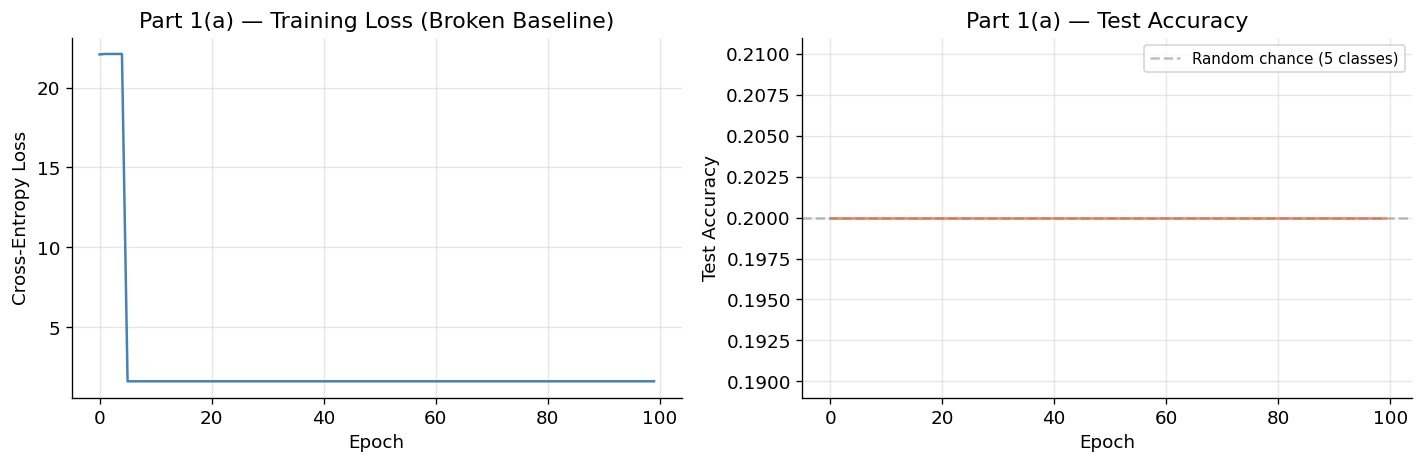

In [6]:
def train_sgd(net, X_tr, Y_tr, X_te, y_te_int, epochs=100, lr=0.01,
              l2_lambda=0.0, dropout_p=0.0,
              log_epochs=(1, 10, 50, 100), verbose=True):
    """Full-batch SGD training loop. Returns train_losses, test_accs."""
    train_losses, test_accs = [], []
    for epoch in range(1, epochs + 1):
        y_hat = net.forward(X_tr, training=True, dropout_p=dropout_p)
        loss  = cross_entropy_loss(y_hat, Y_tr)
        if l2_lambda > 0:
            for l in range(1, net.L + 1):
                loss += 0.5 * l2_lambda * np.sum(net.params[f'W{l}']**2)
        grads = net.backward(Y_tr, l2_lambda=l2_lambda, dropout_p=dropout_p)
        for l in range(1, net.L + 1):
            net.params[f'W{l}'] -= lr * grads[f'dW{l}']
            net.params[f'b{l}'] -= lr * grads[f'db{l}']
        acc = accuracy(net.predict(X_te), y_te_int)
        train_losses.append(loss); test_accs.append(acc)
        if verbose and epoch in log_epochs:
            print(f"  Epoch {epoch:4d} | loss={loss:.4f} | test_acc={acc:.4f}")
    return train_losses, test_accs

# ── Part 1(a): Train the broken baseline ─────────────────────────────────────
np.random.seed(GLOBAL_SEED)
X_tr1, Y_tr1, X_te1, Y_te1, y_tr1, y_te1 = load_dataset(n_classes=5)
LAYER_DIMS_P1 = [784, 128, 64, 32, 16, 5]

baseline_net = DeepMLP(LAYER_DIMS_P1, init='standard', seed=0)
print("Training baseline (standard init, vanilla SGD) on Fashion-MNIST 5-class subset...")
p1_losses, p1_accs = train_sgd(
    baseline_net, X_tr1, Y_tr1, X_te1, y_te1,
    epochs=100, lr=0.01, log_epochs=(1, 10, 50, 100))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(p1_losses, color='steelblue')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Part 1(a) — Training Loss (Broken Baseline)')
axes[1].plot(p1_accs, color='coral')
axes[1].axhline(0.2, color='gray', linestyle='--', alpha=0.5, label='Random chance (5 classes)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Part 1(a) — Test Accuracy'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()


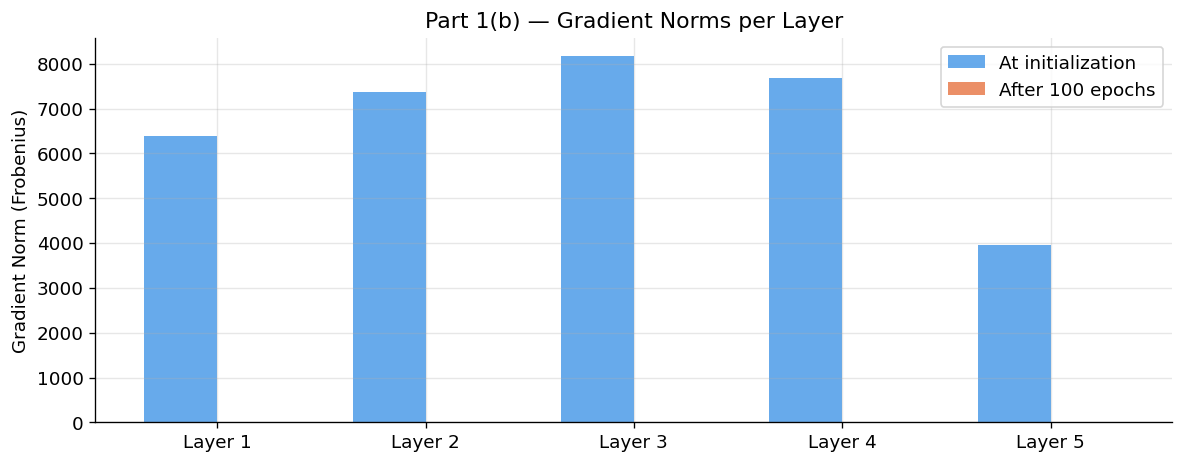

Gradient norms at init:     ['6397.206', '7373.021', '8175.721', '7694.126', '3961.405']
Gradient norms after train: ['0.000', '0.000', '0.000', '0.000', '0.000']


In [7]:
# ── Part 1(b): Gradient norms at initialization vs. epoch 100 ────────────────
np.random.seed(GLOBAL_SEED)
net_init = DeepMLP(LAYER_DIMS_P1, init='standard', seed=0)
_ = net_init.forward(X_tr1, training=False)
grads_init   = net_init.backward(Y_tr1)
norms_init   = net_init.compute_grad_norms(grads_init)

_ = baseline_net.forward(X_tr1, training=False)
grads_trained = baseline_net.backward(Y_tr1)
norms_trained = baseline_net.compute_grad_norms(grads_trained)

n_layers = len(LAYER_DIMS_P1) - 1
x = np.arange(n_layers); w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w/2, norms_init,    w, label='At initialization', color='#4c9be8', alpha=0.85)
ax.bar(x + w/2, norms_trained, w, label='After 100 epochs',  color='#e87b4c', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'Layer {i+1}' for i in range(n_layers)])
ax.set_ylabel('Gradient Norm (Frobenius)')
ax.set_title('Part 1(b) — Gradient Norms per Layer')
ax.legend(); plt.tight_layout(); plt.show()
print("Gradient norms at init:    ", [f"{v:.3f}" for v in norms_init])
print("Gradient norms after train:", [f"{v:.3f}" for v in norms_trained])


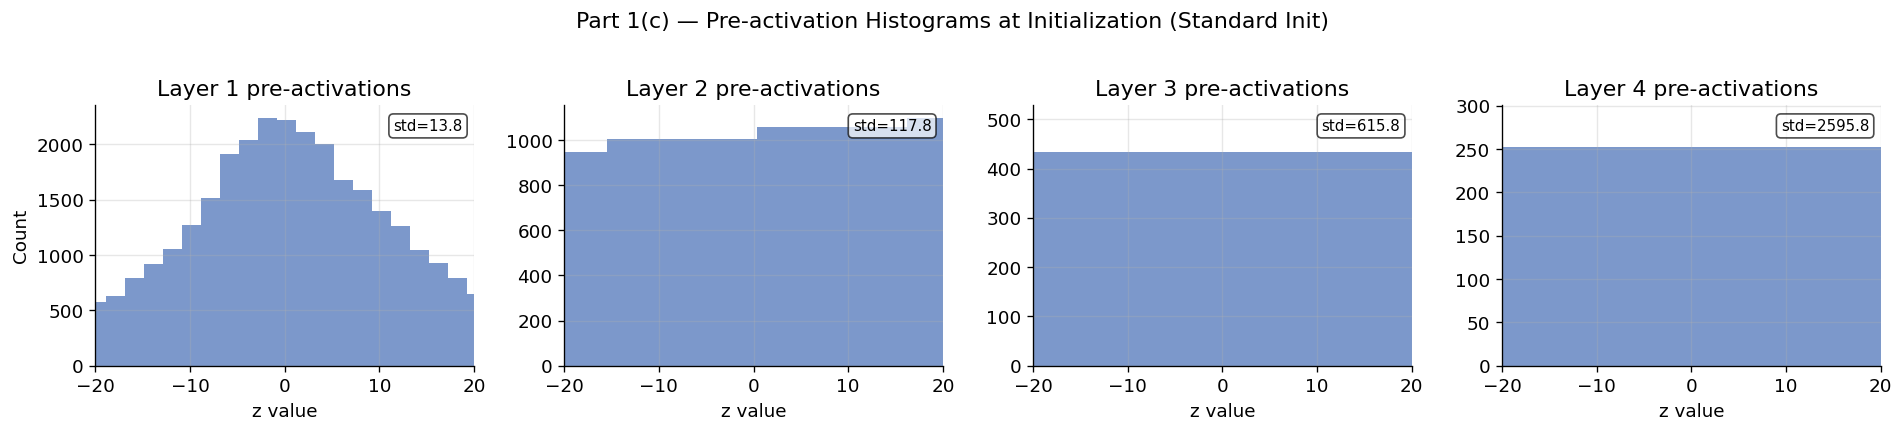

In [8]:
# ── Part 1(c): Pre-activation histograms at initialization ───────────────────
np.random.seed(GLOBAL_SEED)
net_hist = DeepMLP(LAYER_DIMS_P1, init='standard', seed=0)
idx_b = np.random.choice(len(X_tr1), min(256, len(X_tr1)), replace=False)
_ = net_hist.forward(X_tr1[idx_b], training=False)

n_hidden = net_hist.L - 1
fig, axes = plt.subplots(1, n_hidden, figsize=(4 * n_hidden, 3.5))
for l_idx, l in enumerate(range(1, net_hist.L)):
    z = net_hist.cache[f'z{l}'].flatten()
    axes[l_idx].hist(z, bins=60, color='#5b7fbf', edgecolor='none', alpha=0.8)
    axes[l_idx].set_xlim(-20, 20)
    axes[l_idx].set_title(f'Layer {l} pre-activations')
    axes[l_idx].set_xlabel('z value')
    if l_idx == 0: axes[l_idx].set_ylabel('Count')
    axes[l_idx].text(0.97, 0.95, f'std={z.std():.1f}',
                     transform=axes[l_idx].transAxes, ha='right', va='top',
                     fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.7))
plt.suptitle('Part 1(c) — Pre-activation Histograms at Initialization (Standard Init)', y=1.02)
plt.tight_layout(); plt.show()


### Part 1(d) — Analysis (5 pts)

**(i) Gradient norms:** What pattern do you observe across layers? Name the phenomenon.

**ANSWER: At initialization, gradient norms are very large for all of the layers, showing potential exploding gradients. After training, all gradient norms are zero, showing a clear example of vanishing gradients, and causing a dead network.**

**(ii) Pre-activation distributions:** What happens to variance with depth? Why is this a problem?

**ANSWER: With increasing depth, the variance (standard deviation) of the pre-activations grows rapidly. This makes sense, because with random normal initialization, the variance of each z value is basically the variance from the input, multiplied by the number of nodes in the previous layer. This exploding variance makes it almost impossible to find any real pattern in the data, and can lead to issues with large values/overflow.**

**(iii) ReLU interaction:** How does the ReLU derivative interact with the distribution problems in (ii)?

**ANSWER: The relu derivative makes the issue from (ii) worse, because as the variance rapidly increases due to the distribution issue, more values fall into the negative region, where the relu derivative is zero, so they "vanish". As depth increases, increasing variance leads to more dead neurons, making the network too sparse to learn well.**

**(iv) Priorities:** Which two components would you fix first and why?

**ANSWER: The first part to fix would be the weight initialization method, because the standard normal initialization causes the variance to grow rapidly with depth (causing the issues mentioned above). The second thing to fix would be adding normalization to stabilize the distribution of pre-activations (from part (ii)), and keep the values/variance from growing out of control.**

---
# Part 2: Regularization — Preventing Overfitting (16 points)

**Architecture:** `[784, 256, 256, 10]`  
**Optimizer:** SGD, $\eta = 0.05$, full-batch, 300 epochs  
**Data:** 5-class Fashion-MNIST, only **200 training examples** to reliably induce overfitting


In [9]:
np.random.seed(GLOBAL_SEED)
X_tr2, Y_tr2, X_te2, Y_te2, y_tr2, y_te2 = load_dataset(
    n_classes=5, n_train=200, n_test=500)
print(f"Training set: {X_tr2.shape}  |  Test set: {X_te2.shape}")
LAYER_DIMS_P2 = [784, 256, 256, 5]
P2_LR = 0.05; P2_EPOCHS = 300


Training set: (200, 784)  |  Test set: (500, 784)


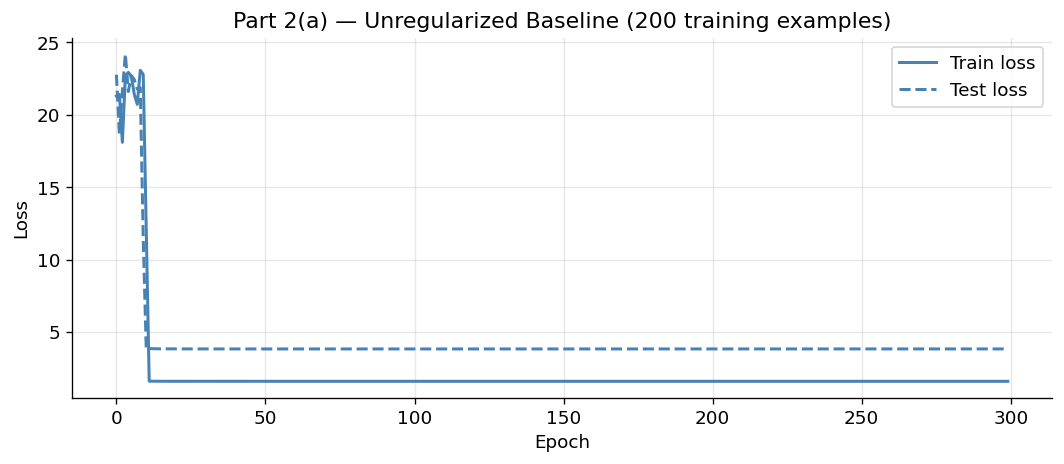

Final train acc: 0.2600
Final test  acc: 0.1900
Generalization gap: 0.0700


In [10]:
def compute_test_loss(net, X_te, Y_te):
    return cross_entropy_loss(net.predict(X_te), Y_te)

def train_with_tracking(net, X_tr, Y_tr, X_te, Y_te, y_te_int,
                        epochs, lr, l2_lambda=0.0, dropout_p=0.0):
    """Returns train_losses, test_losses, test_accs per epoch."""
    train_losses, test_losses, test_accs = [], [], []
    for epoch in range(1, epochs + 1):
        y_hat = net.forward(X_tr, training=True, dropout_p=dropout_p)
        loss  = cross_entropy_loss(y_hat, Y_tr)
        if l2_lambda > 0:
            for l in range(1, net.L + 1):
                loss += 0.5 * l2_lambda * np.sum(net.params[f'W{l}']**2)
        grads = net.backward(Y_tr, l2_lambda=l2_lambda, dropout_p=dropout_p)
        for l in range(1, net.L + 1):
            net.params[f'W{l}'] -= lr * grads[f'dW{l}']
            net.params[f'b{l}'] -= lr * grads[f'db{l}']
        train_losses.append(loss)
        test_losses.append(compute_test_loss(net, X_te, Y_te))
        test_accs.append(accuracy(net.predict(X_te), y_te_int))
    return train_losses, test_losses, test_accs

# ── 2(a): Unregularized baseline ─────────────────────────────────────────────
np.random.seed(GLOBAL_SEED)
net_unreg = DeepMLP(LAYER_DIMS_P2, init='standard', seed=42)
tr_loss_unreg, te_loss_unreg, te_acc_unreg = train_with_tracking(
    net_unreg, X_tr2, Y_tr2, X_te2, Y_te2, y_te2, P2_EPOCHS, P2_LR)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tr_loss_unreg, label='Train loss', color='steelblue', lw=1.8)
ax.plot(te_loss_unreg, label='Test loss',  color='steelblue', linestyle='--', lw=1.8)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Part 2(a) — Unregularized Baseline (200 training examples)')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Final train acc: {accuracy(net_unreg.predict(X_tr2), y_tr2):.4f}")
print(f"Final test  acc: {te_acc_unreg[-1]:.4f}")
print(f"Generalization gap: {accuracy(net_unreg.predict(X_tr2), y_tr2) - te_acc_unreg[-1]:.4f}")


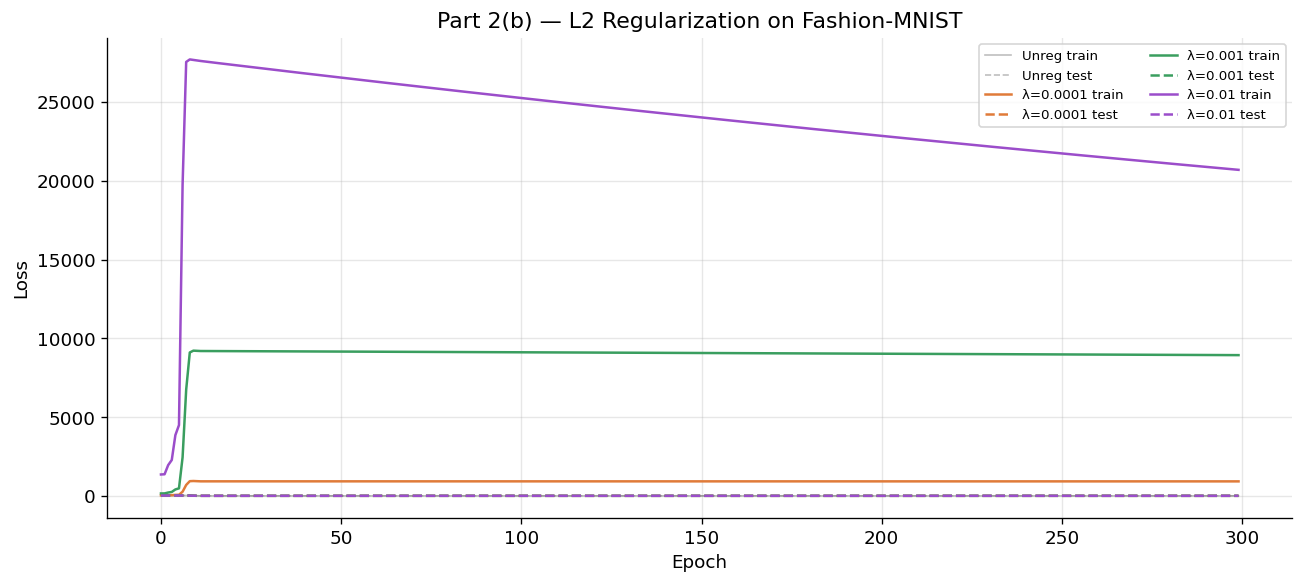

Final test accuracies:
  Unregularized: 0.1900
  λ=0.0001: 0.1900
  λ=0.001: 0.1900
  λ=0.01: 0.2080


In [11]:
# ── 2(b): L2 regularization ───────────────────────────────────────────────────
l2_lambdas = [0.0001, 0.001, 0.01]
colors_l2  = ['#e07b39', '#3a9e5f', '#9b4dca']
l2_results = {}

for lam, col in zip(l2_lambdas, colors_l2):
    np.random.seed(GLOBAL_SEED)
    net = DeepMLP(LAYER_DIMS_P2, init='standard', seed=42)
    tr_l, te_l, te_a = train_with_tracking(
        net, X_tr2, Y_tr2, X_te2, Y_te2, y_te2, P2_EPOCHS, P2_LR, l2_lambda=lam)
    l2_results[lam] = (tr_l, te_l, te_a, net)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tr_loss_unreg, color='gray', lw=1, alpha=0.5, label='Unreg train')
ax.plot(te_loss_unreg, color='gray', lw=1, alpha=0.5, ls='--', label='Unreg test')
for lam, col in zip(l2_lambdas, colors_l2):
    tr_l, te_l, _, _ = l2_results[lam]
    ax.plot(tr_l, color=col, lw=1.5, label=f'λ={lam} train')
    ax.plot(te_l, color=col, lw=1.5, ls='--', label=f'λ={lam} test')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Part 2(b) — L2 Regularization on Fashion-MNIST')
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()
print("Final test accuracies:")
print(f"  Unregularized: {te_acc_unreg[-1]:.4f}")
for lam in l2_lambdas:
    print(f"  λ={lam}: {l2_results[lam][2][-1]:.4f}")


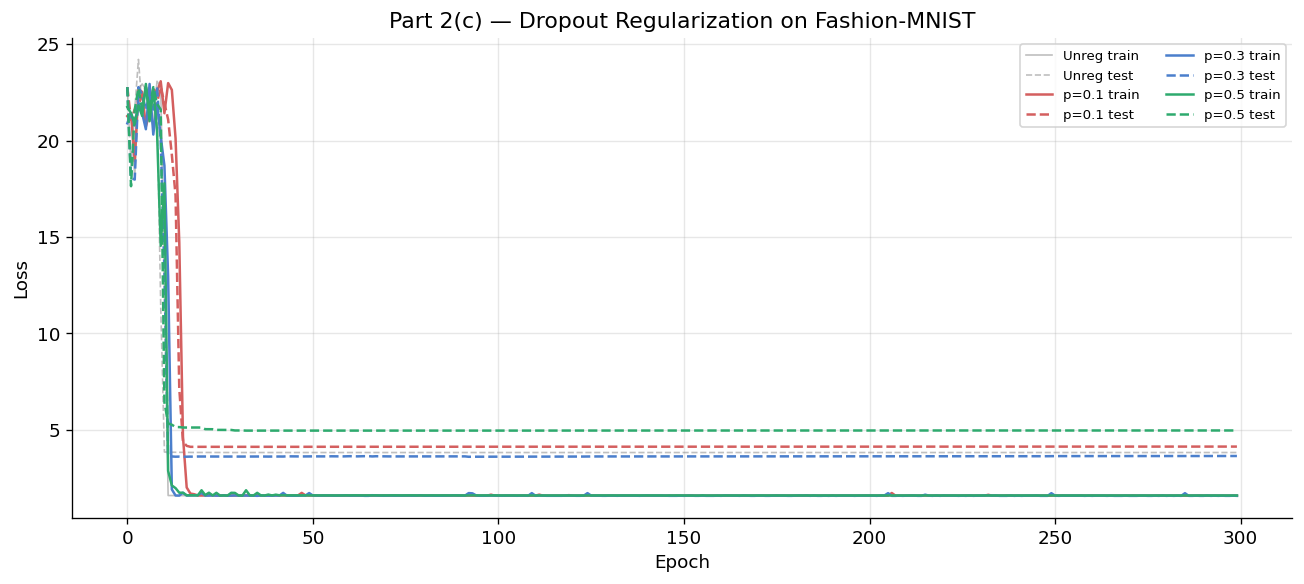

Final test accuracies:
  Unregularized: 0.1900
  p=0.1: 0.1900
  p=0.3: 0.2120
  p=0.5: 0.1800


In [12]:
# ── 2(c): Dropout ─────────────────────────────────────────────────────────────
# NOTE: inverted dropout is implemented in DeepMLP.forward().
# During training: mask = Bernoulli(1-p) / (1-p) applied to each hidden layer.
# During eval: no masking, no scaling needed (inverted dropout handles this).
dropout_ps = [0.1, 0.3, 0.5]
do_colors  = ['#d45f5f', '#4b7fcc', '#2eaa6e']
dropout_results = {}

for p, col in zip(dropout_ps, do_colors):
    np.random.seed(GLOBAL_SEED)
    net = DeepMLP(LAYER_DIMS_P2, init='standard', seed=42)
    tr_l, te_l, te_a = train_with_tracking(
        net, X_tr2, Y_tr2, X_te2, Y_te2, y_te2, P2_EPOCHS, P2_LR, dropout_p=p)
    dropout_results[p] = (tr_l, te_l, te_a, net)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tr_loss_unreg, color='gray', lw=1, alpha=0.5, label='Unreg train')
ax.plot(te_loss_unreg, color='gray', lw=1, alpha=0.5, ls='--', label='Unreg test')
for p, col in zip(dropout_ps, do_colors):
    tr_l, te_l, _, _ = dropout_results[p]
    ax.plot(tr_l, color=col, lw=1.5, label=f'p={p} train')
    ax.plot(te_l, color=col, lw=1.5, ls='--', label=f'p={p} test')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Part 2(c) — Dropout Regularization on Fashion-MNIST')
ax.legend(fontsize=8, ncol=2); plt.tight_layout(); plt.show()
print("Final test accuracies:")
print(f"  Unregularized: {te_acc_unreg[-1]:.4f}")
for p in dropout_ps:
    print(f"  p={p}: {dropout_results[p][2][-1]:.4f}")


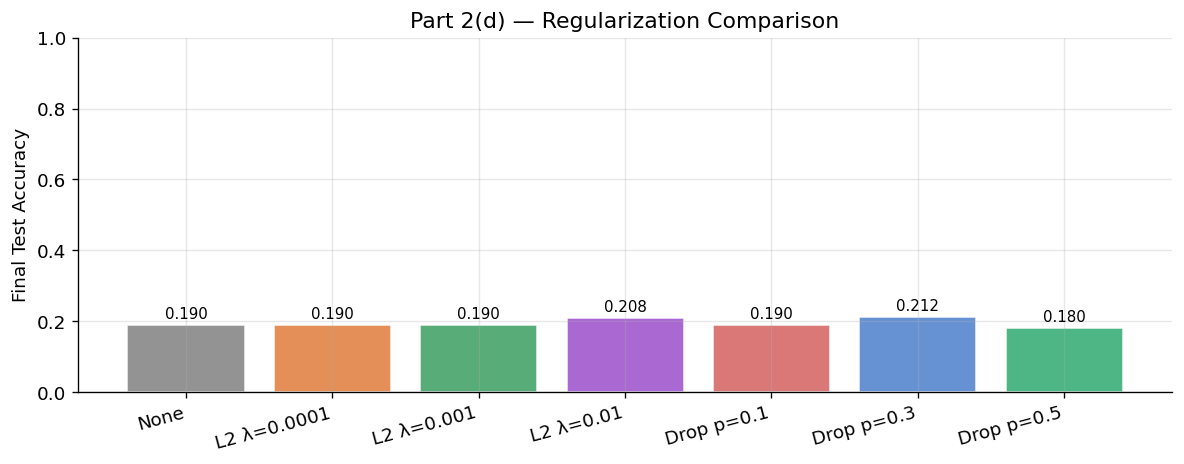

In [13]:
# ── 2(d): Summary bar chart ───────────────────────────────────────────────────
labels   = ['None'] + [f'L2 λ={l}' for l in l2_lambdas] + [f'Drop p={p}' for p in dropout_ps]
accs_all = ([te_acc_unreg[-1]]
            + [l2_results[l][2][-1]  for l in l2_lambdas]
            + [dropout_results[p][2][-1] for p in dropout_ps])
bar_colors = ['gray'] + colors_l2 + do_colors

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, accs_all, color=bar_colors, alpha=0.85, edgecolor='white')
ax.set_ylabel('Final Test Accuracy'); ax.set_title('Part 2(d) — Regularization Comparison')
ax.set_ylim(0, 1.0)
for bar, val in zip(bars, accs_all):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=15, ha='right'); plt.tight_layout(); plt.show()


### ✏️ Part 2(d) — Analysis (4 pts)

**(i) L2:** Which λ worked best? What happens when λ is too large?

**ANSWER: The best lambda was 0.01, with the best test accuracy of 0.208. When lambda is too large, the model pushes weights too far towards zero, leading to overfitting. This causes the model to behave closer to a linear model (not powerful enough to find the real pattern).**

**(ii) Dropout:** Why does dropout raise training loss even if test loss improves?

**ANSWER: Dropout raises training loss because it randomly disables neurons during training, which makes the optimization problem harder. This effectively reduces the capacity of the network overall (because during training, the models are smaller). However, because the dropout also helps prevent co-adaptation, the model can generalize better, and the test loss improves.**

**(iii) L2 vs. Dropout:** Which performed better on Fashion-MNIST and why?

**ANSWER: Dropout (p=0.3) worked slightly better than L2 on this dataset. This is most likely because for this dataset, the model needs to learn to recognize visual features throughout each image. Dropout reduces internal co-adaptation, allowing the model to find better, more robust patterns in the image.**

**(iv) Weight magnitude:** Why does penalizing large weights act as regularization?

**ANSWER: Penalizing large weights acts like regularization because it limits the complexity of the function the model can represent. Smaller weights have lower variance, making the model smoother and less likely to overfit.**

---
# Part 3: Optimizers — Getting Past SGD (17 points)

**Architecture:** `[784, 128, 64, 10]`  
**Init:** Xavier (provided)  
**Epochs:** 200, full-batch  
**Data:** 5-class Fashion-MNIST


In [79]:
class SGDOptimizer:
    """SGD with optional momentum. momentum=0.0 → vanilla SGD."""
    def __init__(self, lr=0.01, momentum=0.0):
        self.lr = lr; self.momentum = momentum; self.velocity = {}

    def update(self, params, grads, layer_dims):
        """Update params in-place."""
        L = len(layer_dims) - 1
        # TODO: implement momentum SGD update
        
        for layer in range(1, L + 1):
            W_key = f"W{layer}"
            b_key = f"b{layer}"

            if self.momentum > 0:
                # Set up the dictionary value
                if W_key not in self.velocity:
                    self.velocity[W_key] = np.zeros_like(params[W_key])
                if b_key not in self.velocity:                    
                    self.velocity[b_key] = np.zeros_like(params[b_key])

                # Update momentum
                self.velocity[W_key] = (self.momentum * self.velocity[W_key]) - (self.lr * grads[f"dW{layer}"])
                self.velocity[b_key] = (self.momentum * self.velocity[b_key]) - (self.lr * grads[f"db{layer}"])

                # Update params
                params[W_key] += self.velocity[W_key]
                params[b_key] += self.velocity[b_key]
            else:
                # Default SGD
                params[W_key] -= self.lr * grads[f"dW{layer}"]
                params[b_key] -= self.lr * grads[f"db{layer}"]

class RMSPropOptimizer:
    """
    RMSProp: element-wise adaptive learning rates.
    s_t = rho*s_{t-1} + (1-rho)*g^2
    w   = w - lr * g / (sqrt(s_t) + eps)
    """
    def __init__(self, lr=0.001, rho=0.9, eps=1e-8):
        self.lr = lr; self.rho = rho; self.eps = eps; self.s = {}

    def update(self, params, grads, layer_dims):
        L = len(layer_dims) - 1
        # TODO: implement RMSProp update
        
        for layer in range(1, L + 1):
            # Run for W and b
            for key in [f"W{layer}", f"b{layer}"]:
                grad_key = f"d{key}"

                # Init the average dict
                if key not in self.s:
                    self.s[key] = np.zeros_like(params[key])

                # Update the average (given formula)
                self.s[key] = (self.rho * self.s[key]) + (1 - self.rho) * (grads[grad_key] ** 2)

                # Update the parameter
                params[key] -= self.lr * grads[grad_key] / (np.sqrt(self.s[key]) + self.eps)

class AdamOptimizer:
    """
    Adam: adaptive moments with bias correction.
    m_t = beta1*m + (1-beta1)*g
    v_t = beta2*v + (1-beta2)*g^2
    m_hat = m_t / (1-beta1^t),  v_hat = v_t / (1-beta2^t)
    w = w - lr * m_hat / (sqrt(v_hat) + eps)
    """
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr=lr; self.beta1=beta1; self.beta2=beta2; self.eps=eps
        self.m={}; self.v={}; self.t=0

    def update(self, params, grads, layer_dims):
        self.t += 1
        L = len(layer_dims) - 1
        # TODO: implement Adam update

        for layer in range(1, L + 1):
            # Run for W and b
            for key in [f"W{layer}", f"b{layer}"]:
                g = grads[f"d{key}"]

                # Init dicts
                if key not in self.m:
                    self.m[key] = np.zeros_like(params[key])
                    self.v[key] = np.zeros_like(params[key])

                # m_t and v_t
                self.m[key] = self.beta1 * self.m[key] + (1 - self.beta1) * g
                self.v[key] = self.beta2 * self.v[key] + (1 - self.beta2) * (g ** 2)

                # m_hat and v_hat
                m_hat = self.m[key] / (1 - (self.beta1 ** self.t))
                v_hat = self.v[key] / (1 - (self.beta2 ** self.t))
                
                # Update the parameter
                params[key] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)


In [15]:
# ── Optimizer sanity check ────────────────────────────────────────────────────
_ld = [784, 32, 5]
for OptCls, kw in [(SGDOptimizer, {'lr':0.01,'momentum':0.9}),
                   (RMSPropOptimizer, {'lr':0.001}),
                   (AdamOptimizer, {'lr':0.001})]:
    _n = DeepMLP(_ld, init='xavier', seed=0)
    _o = OptCls(**kw)
    _ = _n.forward(X_tr1[:16])
    _g = _n.backward(Y_tr1[:16])
    _o.update(_n.params, _g, _ld)
    print(f"✓ {OptCls.__name__} update OK")


✓ SGDOptimizer update OK
✓ RMSPropOptimizer update OK
✓ AdamOptimizer update OK


  SGD (β=0)            | final loss=0.5776 | test_acc=0.8027
  SGD+Momentum         | final loss=0.3359 | test_acc=0.8758
  RMSProp              | final loss=0.3290 | test_acc=0.8515
  Adam                 | final loss=0.2079 | test_acc=0.9052


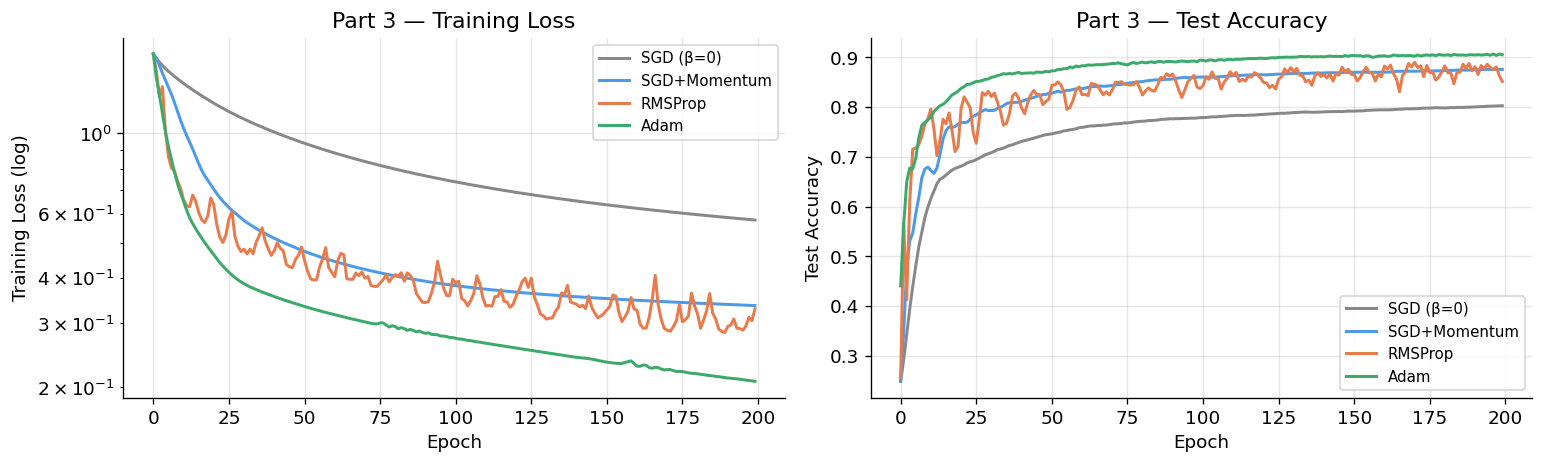


--- Final Results Table ---
Optimizer            | Final Test Acc
--------------------------------------
SGD (β=0)            |         0.8027
SGD+Momentum         |         0.8758
RMSProp              |         0.8515
Adam                 |         0.9052


In [16]:
def train_with_optimizer(net, optimizer, X_tr, Y_tr, X_te, y_te_int,
                         epochs=200, batch_size=None, l2_lambda=0.0, dropout_p=0.0):
    """Generic training loop accepting any optimizer object."""
    train_losses, test_accs = [], []
    N = X_tr.shape[0]
    for epoch in range(1, epochs + 1):
        batches = [(X_tr, Y_tr)] if batch_size is None else list(
            get_minibatches(X_tr, Y_tr, batch_size, seed=epoch))
        epoch_loss = 0.0
        for Xb, Yb in batches:
            y_hat = net.forward(Xb, training=True, dropout_p=dropout_p)
            loss  = cross_entropy_loss(y_hat, Yb)
            if l2_lambda > 0:
                for l in range(1, net.L + 1):
                    loss += 0.5 * l2_lambda * np.sum(net.params[f'W{l}']**2)
            grads = net.backward(Yb, l2_lambda=l2_lambda, dropout_p=dropout_p)
            optimizer.update(net.params, grads, net.layer_dims)
            epoch_loss += loss * len(Xb) / N
        train_losses.append(epoch_loss)
        test_accs.append(accuracy(net.predict(X_te), y_te_int))
    return train_losses, test_accs

LAYER_DIMS_P3 = [784, 128, 64, 5]; P3_EPOCHS = 200

configs = [
    ('SGD (β=0)',    SGDOptimizer(lr=0.01, momentum=0.0)),
    ('SGD+Momentum', SGDOptimizer(lr=0.01, momentum=0.9)),
    ('RMSProp',      RMSPropOptimizer(lr=0.001)),
    ('Adam',         AdamOptimizer(lr=0.001)),
]
p3_results = {}
for name, opt in configs:
    np.random.seed(GLOBAL_SEED)
    net = DeepMLP(LAYER_DIMS_P3, init='xavier', seed=0)
    losses, accs = train_with_optimizer(net, opt, X_tr1, Y_tr1, X_te1, y_te1, epochs=P3_EPOCHS)
    p3_results[name] = (losses, accs)
    print(f"  {name:20s} | final loss={losses[-1]:.4f} | test_acc={accs[-1]:.4f}")

line_colors = ['#888888','#4c9be8','#e87b4c','#3daa6b']
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for (name, _), col in zip(configs, line_colors):
    losses, accs = p3_results[name]
    axes[0].plot(losses, label=name, color=col, lw=1.8)
    axes[1].plot(accs,   label=name, color=col, lw=1.8)
axes[0].set_yscale('log'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss (log)'); axes[0].set_title('Part 3 — Training Loss')
axes[0].legend(fontsize=9)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Part 3 — Test Accuracy'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print("\n--- Final Results Table ---")
print(f"{'Optimizer':<20} | {'Final Test Acc':>14}")
print("-" * 38)
for name, _ in configs:
    print(f"{name:<20} | {p3_results[name][1][-1]:>14.4f}")


### ✏️ Part 3(e) — Analysis (3 pts)

**(i) SGD vs. Momentum:** What geometric effect does momentum have on the trajectory?

**ANSWER: Momentum smooths the trajectory (shown in the plots above) by forcing change in direction to be gradual (based on velocity).**

**(ii) RMSProp adaptive rates:** What is the purpose of dividing by $\sqrt{s^{(t)}+\epsilon}$?

**ANSWER: Since st is an average of the gradient for a parameter, dividing by that value scales the parameters by how much they change. Effectively, steps for parameters that change frequently or by large amounts are scaled down, and steps for parameters that rarely change are scaled up. This lets us have dynamic step size per-parameter.**

**(iii) Adam bias correction:** Why is it necessary at early timesteps? Compute $\hat{m}^{(t)}/m^{(t)}$ at $t=1$ and $t=100$ for $\beta_1=0.9$.

**ANSWER: At early timesteps, mt and vt are pulled towards zero, because they are initialized to zero at the start, so the moving average causes the model to underestimate at first (if not corrected for the zero bias).**

**At t=1: $\frac{1}{1-0.9^1} = \frac{1}{0.1} = 10$**

**At t=100: $\frac{1}{1-0.9^100} = \frac{1}{0.00002656139} = 1.000026562$**

**(iv) Recommendation:** Which optimizer would you use for the rest of this assignment and why?

**ANSWER: I would definitely use Adam for the rest of this assignment because it consistently has the best performance (as shown above). It combines all of the benefits of the other models (momentum, per-parameter updates), while also correcting the bias for early estimates.**


---
# Part 4: Weight Initialization & Vanishing/Exploding Gradients (17 points)

**Architecture:** `[784, 128, 64, 32, 16, 10]`  
**Optimizer:** Adam (`lr=0.001`)  
**Epochs:** 100, full-batch  
**Data:** 5-class Fashion-MNIST


In [17]:
# ── 4(a): Verify Xavier and He ────────────────────────────────────────────────
np.random.seed(GLOBAL_SEED)
fan_in, fan_out = 512, 256
W_std    = standard_init(fan_in, fan_out)
W_xavier = xavier_init(fan_in, fan_out)
W_he     = he_init(fan_in, fan_out)

var_xavier_theory = 2.0 / (fan_in + fan_out)
var_he_theory     = 2.0 / fan_in

print("Initialization variance check:")
print(f"  Standard | empirical: {W_std.var():.5f}    | theoretical: 1.00000")
print(f"  Xavier   | empirical: {W_xavier.var():.5f} | theoretical: {var_xavier_theory:.5f}")
print(f"  He       | empirical: {W_he.var():.5f}    | theoretical: {var_he_theory:.5f}")

for name, emp, theory in [('Xavier', W_xavier.var(), var_xavier_theory),
                           ('He',     W_he.var(),     var_he_theory)]:
    rel = abs(emp - theory) / theory
    print(f"  {name} relative error: {rel:.4f}  {'✓' if rel < 0.10 else '✗ CHECK IMPLEMENTATION'}")


Initialization variance check:
  Standard | empirical: 1.00031    | theoretical: 1.00000
  Xavier   | empirical: 0.00261 | theoretical: 0.00260
  He       | empirical: 0.00392    | theoretical: 0.00391
  Xavier relative error: 0.0004  ✓
  He relative error: 0.0024  ✓


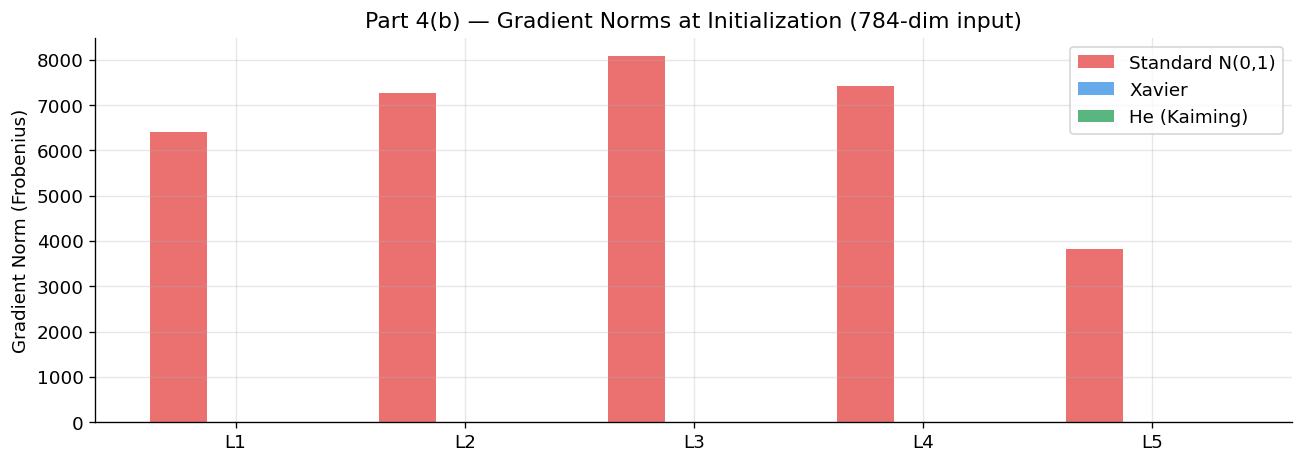

Standard N(0,1)     : ['6406.754', '7261.601', '8085.696', '7420.264', '3820.944']
Xavier              : ['0.937', '0.312', '0.181', '0.143', '0.147']
He (Kaiming)        : ['5.571', '2.539', '1.987', '1.269', '0.424']


In [18]:
# ── 4(b): Gradient norms at initialization — all three schemes ────────────────
LAYER_DIMS_P4  = [784, 128, 64, 32, 16, 5]
init_schemes   = ['standard', 'xavier', 'he']
scheme_labels  = ['Standard N(0,1)', 'Xavier', 'He (Kaiming)']
scheme_colors  = ['#e85858', '#4c9be8', '#3daa6b']
n_layers_p4    = len(LAYER_DIMS_P4) - 1

all_norms = {}
np.random.seed(GLOBAL_SEED)
for scheme in init_schemes:
    net = DeepMLP(LAYER_DIMS_P4, init=scheme, seed=0)
    idx = np.random.choice(len(X_tr1), min(256, len(X_tr1)), replace=False)
    _ = net.forward(X_tr1[idx], training=False)
    g = net.backward(Y_tr1[idx])
    all_norms[scheme] = net.compute_grad_norms(g)

x = np.arange(n_layers_p4); w = 0.25
fig, ax = plt.subplots(figsize=(11, 4))
for i, (scheme, label, col) in enumerate(zip(init_schemes, scheme_labels, scheme_colors)):
    ax.bar(x + (i-1)*w, all_norms[scheme], w, label=label, color=col, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f'L{i+1}' for i in range(n_layers_p4)])
ax.set_ylabel('Gradient Norm (Frobenius)')
ax.set_title('Part 4(b) — Gradient Norms at Initialization (784-dim input)')
ax.legend(); plt.tight_layout(); plt.show()

for scheme, label in zip(init_schemes, scheme_labels):
    print(f"{label:20s}: {[f'{v:.3f}' for v in all_norms[scheme]]}")


  standard   | loss=7.1129 | acc=0.7283
  xavier     | loss=0.2811 | acc=0.8925
  he         | loss=0.2712 | acc=0.8960


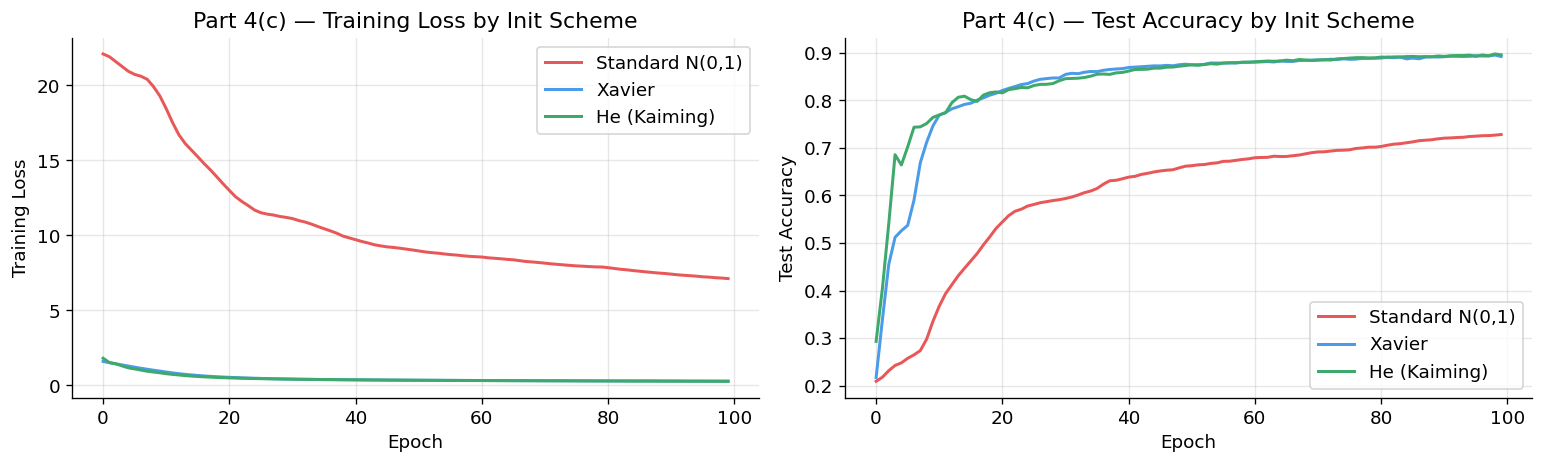

In [19]:
# ── 4(c): Training curves ─────────────────────────────────────────────────────
p4_results = {}
for scheme in init_schemes:
    np.random.seed(GLOBAL_SEED)
    net = DeepMLP(LAYER_DIMS_P4, init=scheme, seed=0)
    opt = AdamOptimizer(lr=0.001)
    losses, accs = train_with_optimizer(net, opt, X_tr1, Y_tr1, X_te1, y_te1, epochs=100)
    p4_results[scheme] = (losses, accs, net)
    print(f"  {scheme:10s} | loss={losses[-1]:.4f} | acc={accs[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for scheme, label, col in zip(init_schemes, scheme_labels, scheme_colors):
    losses, accs, _ = p4_results[scheme]
    axes[0].plot(losses, label=label, color=col, lw=1.8)
    axes[1].plot(accs,   label=label, color=col, lw=1.8)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training Loss')
axes[0].set_title('Part 4(c) — Training Loss by Init Scheme'); axes[0].legend()
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Part 4(c) — Test Accuracy by Init Scheme'); axes[1].legend()
plt.tight_layout(); plt.show()


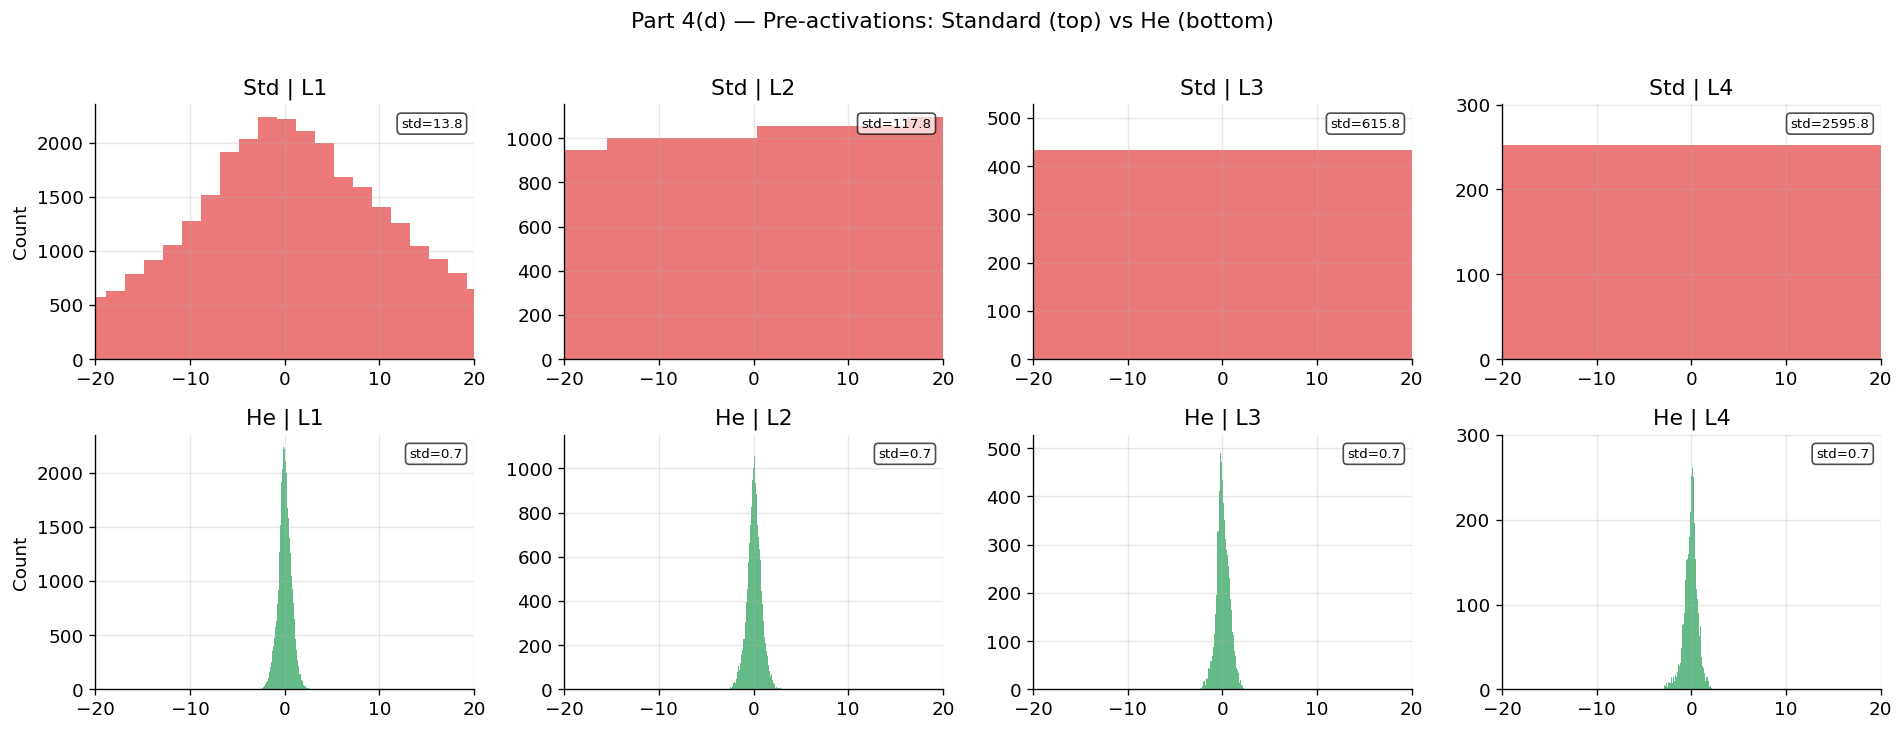

In [20]:
# ── 4(d): Pre-activation histograms: Standard vs. He ─────────────────────────
np.random.seed(GLOBAL_SEED)
fig, axes = plt.subplots(2, n_layers_p4 - 1, figsize=(4*(n_layers_p4-1), 6))
for row, scheme in enumerate(['standard', 'he']):
    net = DeepMLP(LAYER_DIMS_P4, init=scheme, seed=0)
    idx = np.random.choice(len(X_tr1), min(256, len(X_tr1)), replace=False)
    _ = net.forward(X_tr1[idx], training=False)
    col = scheme_colors[0] if scheme == 'standard' else scheme_colors[2]
    for c, l in enumerate(range(1, net.L)):
        z = net.cache[f'z{l}'].flatten()
        axes[row, c].hist(z, bins=60, color=col, edgecolor='none', alpha=0.8)
        axes[row, c].set_xlim(-20, 20)
        axes[row, c].set_title(f'{"Std" if scheme=="standard" else "He"} | L{l}')
        axes[row, c].text(0.97, 0.95, f'std={z.std():.1f}',
                          transform=axes[row,c].transAxes, ha='right', va='top',
                          fontsize=8, bbox=dict(boxstyle='round',fc='white',alpha=0.7))
        if c == 0: axes[row, c].set_ylabel('Count')
plt.suptitle('Part 4(d) — Pre-activations: Standard (top) vs He (bottom)', y=1.01)
plt.tight_layout(); plt.show()


### ✏️ Part 4(e) — Analysis (3 pts)

**(i)** Why does Standard $\mathcal{N}(0,1)$ init cause exploding/vanishing gradients on 784-dim input?

**ANSWER: Standard normal initialization doesn't take the layer size into account, so the variance grows with the size of each layer. With 784-dim input, each neuron sums 784 independent variables, which causes the variance of the activation to also scale by around 784. With each layer, this effect stacks, either causing variance to explode, which causes unstable gradients that immediately explode/vanish.** 

**(ii)** Why might Xavier underperform He for ReLU networks?

**ANSWER: Xavier initialization assumes a symmetric activation function where both positive and negative values continue through the network. For a ReLu network, the activations are all positive (because all negative values are zeroed out by ReLu).**

**(iii)** Did He outperform Xavier in your curves? If the gap is small, explain why.

**ANSWER: He initialization very slightly outperformed Xavier in this test (0.8960 vs. 0.8925). This gap is tiny because both methods stabilize the variance across layers, preventing the explosion seen with standard initialization. Since the network is shallow, there aren't enough layers for Xavier's slight weakness to make a difference.**

**(iv)** If you replaced ReLU with Leaky ReLU ($\alpha=0.01$), would He init still be appropriate?

**ANSWER: Yes, He initialization would still be appropriate. Although Leaky ReLu does allow some negative values to propagate, they are scaled down, leading to an asymmetric activation (smaller negative values, normal positive values), which still gives Xavier initialization a disadvantage.**


---
# Part 5: Batch Normalization (17 points)

**Architecture:** `[784, 256, 128, 64, 10]`  
**Optimizer:** Adam (`lr=0.001`), mini-batch size 128  
**Init:** He  
**Epochs:** 20  
**Data:** Full 10-class Fashion-MNIST (real 60k/10k split)


In [80]:
class BatchNormLayer:
    """
    Batch Normalization: normalizes pre-activations within a mini-batch,
    then applies learned affine transform gamma (scale) and beta (shift).

    Training mode:  use batch mean/var; update running statistics.
    Inference mode: use running mean/var (no batch dependency).
    """

    def __init__(self, n_features, momentum=0.1, eps=1e-8):
        self.gamma = np.ones((1, n_features))    # learned scale, init=1
        self.beta  = np.zeros((1, n_features))   # learned shift, init=0
        self.eps   = eps
        self.momentum = momentum
        self.running_mean = np.zeros((1, n_features))
        self.running_var  = np.ones((1, n_features))
        self.cache = {}

    def forward(self, z, training=True):
        """
        Forward pass. Caches all values needed for backward.
        Returns out of shape (N, D).
        """
        # TODO: implement BN forward

        if training:
            mean = np.mean(z, axis=0, keepdims=True)
            var = np.var(z, axis=0, keepdims=True)

            # Normalize
            z_hat = (z - mean)  / np.sqrt(var + self.eps)

            # Apply the scale and shift
            result = self.gamma * z_hat + self.beta

            # Update stats
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var

            # Cache
            self.cache = {
                "z": z,
                "z_hat": z_hat,
                "mean": mean,
                "var": var,
            }
        else:
            # Just use the existing stats
            z_hat = (z - self.running_mean) / np.sqrt(self.running_var + self.eps)
            result = self.gamma * z_hat + self.beta

        return result


    def backward(self, d_out):
        """
        Backward pass through BN. Returns (dz, d_gamma, d_beta).

        d_gamma = sum_i (d_out_i * z_hat_i)
        d_beta  = sum_i d_out_i
        dz_i    = (gamma / sqrt(var+eps)) / B *
                  [ B*d_out_i
                    - sum_j d_out_j
                    - z_hat_i * sum_j (d_out_j * z_hat_j) ]
        """
        # TODO: implement BN backward
        
        z_hat = self.cache["z_hat"]
        var = self.cache["var"]

        B = d_out.shape[0]

        # d_gamma and d_beta
        d_gamma = np.sum(d_out * z_hat, axis=0, keepdims=True)
        d_beta = np.sum(d_out, axis=0, keepdims=True)

        dz = ((self.gamma / np.sqrt(var + self.eps)) / B) * ((B * d_out) - np.sum(d_out, axis=0, keepdims=True) - (z_hat * np.sum(d_out * z_hat, axis=0, keepdims=True)))

        return dz, d_gamma, d_beta 

In [26]:
# ── BN sanity check ───────────────────────────────────────────────────────────
np.random.seed(GLOBAL_SEED)
_bn = BatchNormLayer(128)
_z  = np.random.randn(256, 128) * 5 + 3   # deliberately off-centre
_o  = _bn.forward(_z, training=True)
assert abs(_o.mean()) < 0.05, f"Mean not near 0: {_o.mean():.4f}"
assert abs(_o.std() - 1.0)  < 0.05, f"Std not near 1: {_o.std():.4f}"
print(f"✓ BN forward check passed | mean={_o.mean():.5f}, std={_o.std():.5f}")


✓ BN forward check passed | mean=0.00000, std=1.00000


In [27]:
def bn_gradient_check(bn_layer, z, d_out, eps=1e-5, tol=1e-4):
    _ = bn_layer.forward(z, training=True)
    dz_a, dg_a, db_a = bn_layer.backward(d_out)

    def loss_fn(z_in):
        bn_copy = BatchNormLayer(z_in.shape[1])
        bn_copy.gamma = bn_layer.gamma.copy(); bn_copy.beta = bn_layer.beta.copy()
        return (bn_copy.forward(z_in, training=True) * d_out).sum()

    print(f"{'Parameter':<25} | {'Analytic':>12} | {'Numerical':>12} | {'Rel Err':>10} | {'Pass?':>6}")
    print("-" * 74)
    all_pass = True
    for (i, j) in [(0,0),(0,1),(1,0),(2,3),(3,5),(4,2)]:
        zp = z.copy(); zp[i,j] += eps
        zm = z.copy(); zm[i,j] -= eps
        num = (loss_fn(zp) - loss_fn(zm)) / (2*eps)
        ana = dz_a[i,j]
        rel = abs(num-ana)/(abs(num)+abs(ana)+1e-12)
        ok = rel < tol; all_pass = all_pass and ok
        print(f"  dz[{i},{j}]{'':<15} | {ana:>12.6f} | {num:>12.6f} | {rel:>10.2e} | {'✓' if ok else '✗':>6}")
    for nm, param, d_ana in [('gamma[0,0]', bn_layer.gamma, dg_a),
                               ('beta[0,0]',  bn_layer.beta,  db_a)]:
        orig = param[0,0]
        param[0,0]=orig+eps; fp=(bn_layer.forward(z,training=True)*d_out).sum()
        param[0,0]=orig-eps; fm=(bn_layer.forward(z,training=True)*d_out).sum()
        param[0,0]=orig
        num=(fp-fm)/(2*eps); ana=d_ana[0,0]
        rel=abs(num-ana)/(abs(num)+abs(ana)+1e-12); ok=rel<tol; all_pass=all_pass and ok
        print(f"  {nm:<23} | {ana:>12.6f} | {num:>12.6f} | {rel:>10.2e} | {'✓' if ok else '✗':>6}")
    print(f"\n{'ALL CHECKS PASSED ✓' if all_pass else 'SOME CHECKS FAILED ✗'}")

np.random.seed(GLOBAL_SEED)
_bn_gc = BatchNormLayer(8)
bn_gradient_check(_bn_gc, np.random.randn(16, 8), np.random.randn(16, 8))


Parameter                 |     Analytic |    Numerical |    Rel Err |  Pass?
--------------------------------------------------------------------------
  dz[0,0]                |    -0.045440 |    -0.045440 |   4.24e-10 |      ✓
  dz[0,1]                |    -1.020472 |    -1.020472 |   1.88e-12 |      ✓
  dz[1,0]                |    -0.864012 |    -0.864012 |   5.75e-12 |      ✓
  dz[2,3]                |    -1.307588 |    -1.307588 |   2.80e-11 |      ✓
  dz[3,5]                |     0.491192 |     0.491192 |   6.43e-11 |      ✓
  dz[4,2]                |     0.974488 |     0.974488 |   1.89e-11 |      ✓
  gamma[0,0]              |     3.940081 |     3.940081 |   1.12e-12 |      ✓
  beta[0,0]               |    -1.673597 |    -1.673597 |   1.02e-12 |      ✓

ALL CHECKS PASSED ✓


In [81]:
class DeepMLPwithBN:
    """MLP with Batch Normalization before each hidden ReLU."""
    def __init__(self, layer_dims, seed=0):
        np.random.seed(seed); self.layer_dims=layer_dims
        self.L=len(layer_dims)-1; self.params={}; self.bn_layers={}; self.cache={}
        for l in range(1, self.L+1):
            fi,fo=layer_dims[l-1],layer_dims[l]
            self.params[f'W{l}']=he_init(fi,fo); self.params[f'b{l}']=np.zeros((1,fo))
            if l < self.L: self.bn_layers[l]=BatchNormLayer(fo)
    def forward(self, X, training=True):
        self.cache['h0']=X; h=X
        for l in range(1, self.L+1):
            z=h@self.params[f'W{l}']+self.params[f'b{l}']; self.cache[f'z{l}']=z
            if l < self.L:
                z_bn=self.bn_layers[l].forward(z,training=training)
                self.cache[f'z_bn{l}']=z_bn; h=relu(z_bn)
            else: h=softmax(z)
            self.cache[f'h{l}']=h
        return h
    def backward(self, y_true):
        grads={}; N=y_true.shape[0]; dz=(self.cache[f'h{self.L}']-y_true)/N
        for l in range(self.L,0,-1):
            grads[f'dW{l}']=self.cache[f'h{l-1}'].T@dz
            grads[f'db{l}']=dz.sum(axis=0,keepdims=True)
            if l>1:
                dz_bn=(dz@self.params[f'W{l}'].T)*(self.cache[f'z_bn{l-1}']>0)
                dz,grads[f'dgamma{l-1}'],grads[f'dbeta{l-1}']=self.bn_layers[l-1].backward(dz_bn)
        return grads
    def update_params(self,grads,optimizer):
        optimizer.update(self.params,grads,self.layer_dims)
        lr=getattr(optimizer,'lr',0.001)
        for l in range(1,self.L):
            if f'dgamma{l}' in grads:
                self.bn_layers[l].gamma-=lr*grads[f'dgamma{l}']
                self.bn_layers[l].beta -=lr*grads[f'dbeta{l}']
    def predict(self,X): return self.forward(X,training=False)

LAYER_DIMS_P5=[784,256,128,64,10]; P5_EPOCHS=20; P5_BATCH=128

def train_net_p5(use_bn):
    np.random.seed(GLOBAL_SEED)
    # Use the real 60k/10k split for Parts 5-6
    mask_tr = y_train_full < 10; mask_te = y_test_full < 10
    X_tr5 = X_train_full[mask_tr]; Y_tr5_int = y_train_full[mask_tr]
    X_te5 = X_test_full[mask_te];  y_te5_int = y_test_full[mask_te]
    def oh(y,n): o=np.zeros((len(y),n)); o[np.arange(len(y)),y]=1; return o
    Y_tr5 = oh(Y_tr5_int, 10)

    net = DeepMLPwithBN(LAYER_DIMS_P5,seed=0) if use_bn else DeepMLP(LAYER_DIMS_P5,init='he',seed=0)
    opt = AdamOptimizer(lr=0.001)
    losses, accs = [], []
    N = X_tr5.shape[0]
    for epoch in range(1, P5_EPOCHS+1):
        epoch_loss=0.0
        for Xb,Yb in get_minibatches(X_tr5,Y_tr5,P5_BATCH,seed=epoch):
            yh=net.forward(Xb,training=True); grads=net.backward(Yb)
            if use_bn: net.update_params(grads,opt)
            else: opt.update(net.params,grads,net.layer_dims)
            epoch_loss+=cross_entropy_loss(yh,Yb)*len(Xb)/N
        losses.append(epoch_loss)
        accs.append(accuracy(net.predict(X_te5),y_te5_int))
    return losses, accs


Training WITHOUT Batch Normalization...
Training WITH Batch Normalization...


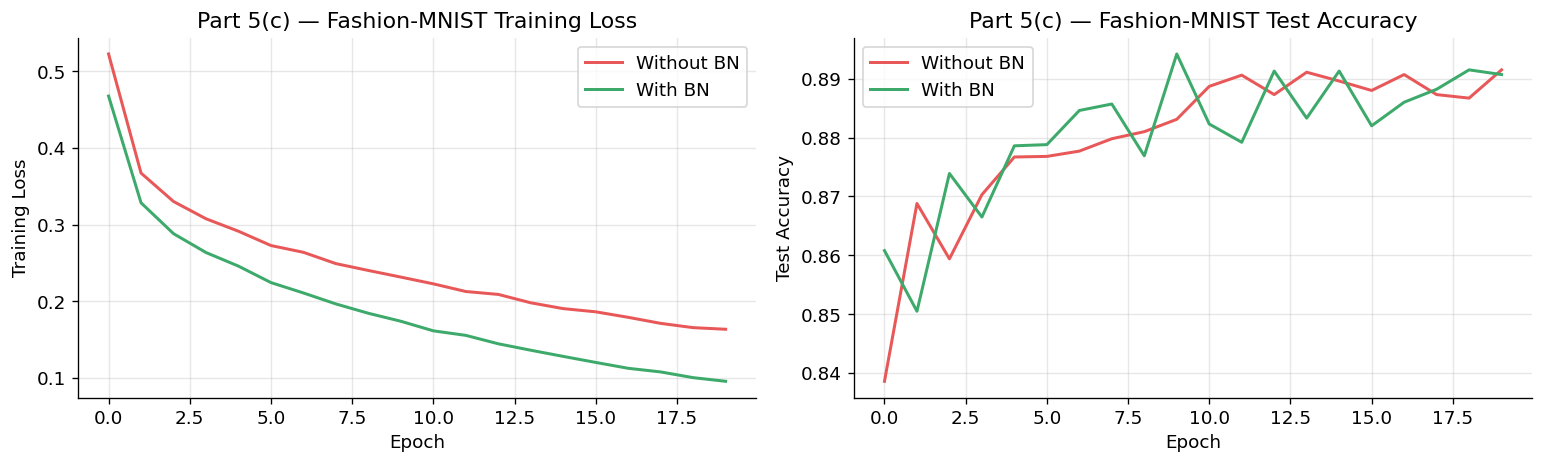


Final test accuracy — No BN: 0.8915 | With BN: 0.8907


In [84]:
print("Training WITHOUT Batch Normalization...")
losses_no_bn, accs_no_bn = train_net_p5(use_bn=False)
print("Training WITH Batch Normalization...")
losses_bn, accs_bn = train_net_p5(use_bn=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(losses_no_bn, label='Without BN', color='#e85858', lw=1.8)
axes[0].plot(losses_bn,    label='With BN',    color='#3daa6b', lw=1.8)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training Loss')
axes[0].set_title('Part 5(c) — Fashion-MNIST Training Loss'); axes[0].legend()
axes[1].plot(accs_no_bn, label='Without BN', color='#e85858', lw=1.8)
axes[1].plot(accs_bn,    label='With BN',    color='#3daa6b', lw=1.8)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Part 5(c) — Fashion-MNIST Test Accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()
print(f"\nFinal test accuracy — No BN: {accs_no_bn[-1]:.4f} | With BN: {accs_bn[-1]:.4f}")

### ✏️ Part 5(d) — Analysis (3 pts)

**(i) Training dynamics:** Describe qualitative differences between BN and non-BN curves.

**ANSWER: With batch normalization, the training loss was consistently lower than without it, and improved smoothly over the course of the training. The BN curve was also slightly smoother than the non-BN curve. Interestingly, the BN curve for test accuracy was mostly similar to the curve without BN, both changing pretty sharply.**

**(ii) BN backward term:** What does $-\frac{1}{B}\sum_j \frac{\partial \mathcal{L}}{\partial y_j}$ correct for?

**ANSWER: This term makes sure that the gradient has a mean of zero for the whole batch, correcting for the zero-mean step in batch normalization.**

**(iii) Inference pathology:** What goes wrong if you use batch stats at inference time?

**ANSWER: Using batch stats at inference time would make predictions depend on the specific batch, instead of the actual learned distribution. This would cause randomness, and inconsistent results depending on how inputs were batched together.**

**(iv) Learnable γ and β:** Why are these parameters necessary?

**ANSWER: γ (scaling) and β (shifting) are required because they let the network still be flexible after normalization. Without them, the network would be forced to learn patterns with zero mean. These parameters let the network "undo" some of the normalization if needed.**


---
# Part 6: Convolutional Neural Networks from Scratch (16 points)

Fashion-MNIST images are 28×28. We keep them in their spatial format `(N, 1, 28, 28)`.

**CNN Architecture:**
```
Conv(1→8, kernel=3, pad=1) → ReLU → MaxPool(2×2)    output: (N, 8, 14, 14)
Conv(8→16, kernel=3, pad=1) → ReLU → MaxPool(2×2)   output: (N, 16, 7, 7)
Flatten → FC(784, 10) → Softmax
```
**Optimizer:** Adam (`lr=0.001`)  **Init:** He  **Epochs:** 15  **Batch:** 128


In [ ]:
def conv_forward(X, W, b, padding=0):
    """
    Naive convolution forward pass (loops over spatial positions).

    Parameters
    ----------
    X       : (N, C_in, H, W_img)
    W       : (C_out, C_in, kH, kW)
    b       : (C_out,)
    padding : int

    Returns
    -------
    out   : (N, C_out, H_out, W_out)
    X_pad : zero-padded input (needed in backward)
    """
    N, C_in, H, W_img = X.shape
    C_out, _, kH, kW  = W.shape

    # TODO: implement conv_forward

    # Padding
    if padding > 0:
        X_pad = np.pad(X, ((0, 0), (0, 0), (padding, padding), (padding, padding)), mode="constant")
    else:
        X_pad = X
    
    H_pad, W_pad = X_pad.shape[2], X_pad.shape[3]

    H_out = H_pad - kH + 1
    W_out = W_pad - kW + 1

    # Build the empty result matrix
    result = np.zeros((N, C_out, H_out, W_out))

    # For each layer, loop over each C, row, and column
    for n in range(N):
        for c_out in range(C_out):
            for i in range(H_out):
                for j in range(W_out):
                    # Get the region
                    region = X_pad[n, :, i:i + kH, j: j + kW]
                    # Do the weighted sum, and add the bias
                    result[n, c_out, i, j] = np.sum(region * W[c_out]) + b[c_out]
    return result, X_pad

def maxpool_forward(X, pool_size=2, stride=2):
    """
    Max pooling forward pass.

    Returns out (N,C,H_out,W_out) and mask (same shape as X,
    1 at max positions — used in backward pass).
    """
    import torch  # TODO(Simon)
    if torch.is_tensor(X):
        X = X.detach().cpu().numpy()
    N, C, H, W = X.shape
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1
    out  = np.zeros((N, C, H_out, W_out))
    mask = np.zeros_like(X)

    # TODO: implement maxpool_forward

    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    # Get the bounds
                    h_start = i * stride
                    h_end = h_start + pool_size
                    w_start = j * stride
                    w_end = w_start + pool_size
                    # Get the region
                    region = X[n, c, h_start:h_end, w_start:w_end]

                    max_val = np.max(region)
                    out[n, c, i, j] = max_val

                    max_mask = (region == max_val)
                    mask[n, c, h_start:h_end, w_start:w_end] += max_mask
    return out, mask


In [ ]:
def maxpool_forward(X, pool_size=2, stride=2):
    N, C, H, W = X.shape
    H_out, W_out = (H - pool_size) // stride + 1, (W - pool_size) // stride + 1
    
    # Numpy trick to separate out {pool size} x {pool size} blocks into dimensions 3 and 5 
    view = X.reshape(N, C, H_out, pool_size, W_out, pool_size)
    out = view.max(axis=(3, 5))  # Get the max of each block
    
    # Resize back to the shape of X, so the mask is the correct size
    mask = (X == out.repeat(pool_size, axis=2).repeat(pool_size, axis=3))
    return out, mask

def maxpool_backward(d_out, mask, pool_size=2, stride=2):
    # Stretch d_out to the size of the mask, and then apply the mask
    return d_out.repeat(pool_size, axis=2).repeat(pool_size, axis=3) * mask

def conv_forward(X, W, b, padding=1):
    N, C_in, H, W_img = X.shape
    C_out, _, kH, kW = W.shape
    
    H_out = (H + 2 * padding - kH) // 1 + 1
    W_out = (W_img + 2 * padding - kW) // 1 + 1
    H_out = int(np.asarray(H_out).item())
    W_out = int(np.asarray(W_out).item())
    
    # Padding
    X_pad = np.pad(X, ((0,0), (0,0), (padding, padding), (padding, padding)))
    
    # Loop over each pixel position
    out = np.zeros((N, C_out, H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            # Get the 3x3 patch of pixels from every image
            region = X_pad[:, :, i:i+kH, j:j+kW]
            # Apply filters to the patch in every image at the same time
            out[:, :, i, j] = np.tensordot(region, W, axes=((1,2,3), (1,2,3))) + b
            
    return out, X_pad

def conv_backward(d_out, X_pad, W, padding=1):
    N, C_out, H_out, W_out = d_out.shape
    C_out, C_in, kH, kW = W.shape
    
    dW = np.zeros_like(W)
    db = np.sum(d_out, axis=(0, 2, 3))
    dX_pad = np.zeros_like(X_pad)
    
    for i in range(H_out):
        for j in range(W_out):
            grad = d_out[:, :, i, j] 
            # Get the patch for every image
            region = X_pad[:, :, i:i+kH, j:j+kW]
            
            # Update dW (sum of the patch in each image)
            dW += np.tensordot(grad, region, axes=((0), (0)))
            # Update dX_pad
            dX_pad[:, :, i:i+kH, j:j+kW] += np.tensordot(grad, W, axes=((1), (0)))
            
    dX = dX_pad[:, :, padding:-padding, padding:-padding] if padding > 0 else dX_pad
    return dX, dW, db

In [63]:
# ── Conv/Pool sanity checks ───────────────────────────────────────────────────
np.random.seed(GLOBAL_SEED)
_X_chk = np.random.randn(4, 1, 28, 28)
_out_cv, _ = conv_forward(_X_chk, np.ones((1,1,3,3)), np.zeros(1), padding=1)
assert _out_cv.shape == (4,1,28,28), f"Expected (4,1,28,28), got {_out_cv.shape}"
print(f"✓ Conv forward shape check passed: {_out_cv.shape}")
_out_mp, _ = maxpool_forward(_out_cv)
assert _out_mp.shape == (4,1,14,14), f"Expected (4,1,14,14), got {_out_mp.shape}"
print(f"✓ MaxPool forward shape check passed: {_out_mp.shape}")


✓ Conv forward shape check passed: (4, 1, 28, 28)
✓ MaxPool forward shape check passed: (4, 1, 14, 14)


In [ ]:
def conv_backward(d_out, X_pad, W, padding=0):
    """
    Backward pass through convolution.

    Returns dX (unpadded), dW, db.

    Gradient formulas:
        dW[c,ci,p,q] = sum_{n,i,j} d_out[n,c,i,j] * X_pad[n,ci,i+p,j+q]
        db[c]        = sum_{n,i,j} d_out[n,c,i,j]
        dX_pad[n,ci,i+p,j+q] += W[c,ci,p,q] * d_out[n,c,i,j]
    """
    N, C_in, _, _  = X_pad.shape
    C_out, _, kH, kW = W.shape
    _, _, H_out, W_out = d_out.shape

    # TODO: implement conv_backward

    dW = np.zeros_like(W)
    db = np.zeros((C_out,))
    dX_pad = np.zeros_like(X_pad)

    for n in range(N):
        for c_out in range(C_out):
            for i in range(H_out):
                for j in range(W_out):
                    grad = d_out[n, c_out, i, j]

                    # db
                    db[c_out] += grad

                    # dW and dX_pad
                    dW[c_out] += grad * X_pad[n, :, i:i+kH, j:j+kW]
                    dX_pad[n, :, i:i+kH, j:j+kW] += grad * W[c_out]

    # Remove padding
    if padding > 0:
        dX = dX_pad[:, :, padding:-padding, padding:-padding]
    else:
        dX = dX_pad

    return dX, dW, db

def maxpool_backward(d_out, mask, pool_size=2, stride=2):
    """
    Max pooling backward: route gradient only to the max position.
    """
    N, C, H_mask, W_mask = mask.shape
    _, _, H_out, W_out = d_out.shape
    dX = np.zeros_like(mask, dtype=np.float64)

    # TODO: implement maxpool_backward

    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                for j in range(W_out):
                    # Get bounds
                    h_start = i * stride
                    h_end = h_start + pool_size
                    w_start = j * stride
                    w_end = w_start + pool_size

                    # Only add gradient to max locations (from mask)
                    grad = d_out[n, c, i, j]
                    dX[n, c, h_start:h_end, w_start:w_end] += mask[n, c, h_start:h_end, w_start:w_end] * grad

    return dX


In [64]:
def conv_gradient_check(eps=1e-5, tol=1e-4):
    np.random.seed(GLOBAL_SEED)
    X = np.random.randn(2, 1, 8, 8) * 0.5
    W = np.random.randn(3, 1, 3, 3) * 0.1
    b = np.random.randn(3) * 0.1
    d_up = np.random.randn(2, 3, 8, 8)
    out, X_pad = conv_forward(X, W, b, padding=1)
    dX, dW, db = conv_backward(d_up, X_pad, W, padding=1)

    def loss_fn(W_in):
        o, _ = conv_forward(X, W_in, b, padding=1)
        return (o * d_up).sum()

    print(f"{'Index':<20} | {'Analytic':>12} | {'Numerical':>12} | {'Rel Err':>10} | {'Pass?':>6}")
    print("-" * 68)
    all_pass = True
    for idx in [(0,0,0,0),(0,0,1,1),(1,0,0,2),(2,0,2,2),(0,0,2,0)]:
        c, ci, p, q = idx
        orig = W[c,ci,p,q]
        W[c,ci,p,q]=orig+eps; fp=loss_fn(W)
        W[c,ci,p,q]=orig-eps; fm=loss_fn(W)
        W[c,ci,p,q]=orig
        num=(fp-fm)/(2*eps); ana=dW[c,ci,p,q]
        rel=abs(num-ana)/(abs(num)+abs(ana)+1e-12); ok=rel<tol; all_pass=all_pass and ok
        idx_str = str(list(idx))
        print(f"  dW{idx_str:<13} | {ana:>12.6f} | {num:>12.6f} | {rel:>10.2e} | {'✓' if ok else '✗':>6}")
    print(f"\n{'ALL PASSED ✓' if all_pass else 'SOME FAILED ✗'}")

conv_gradient_check()


Index                |     Analytic |    Numerical |    Rel Err |  Pass?
--------------------------------------------------------------------
  dW[0, 0, 0, 0]  |     0.772345 |     0.772345 |   2.14e-11 |      ✓
  dW[0, 0, 1, 1]  |     0.379526 |     0.379526 |   2.50e-11 |      ✓
  dW[1, 0, 0, 2]  |    -2.281045 |    -2.281045 |   6.75e-12 |      ✓
  dW[2, 0, 2, 2]  |    -0.219805 |    -0.219805 |   9.34e-12 |      ✓
  dW[0, 0, 2, 0]  |    -1.674688 |    -1.674688 |   1.76e-12 |      ✓

ALL PASSED ✓


  Epoch  1 | loss=0.5707 | test_acc=0.8592
  Epoch  2 | loss=0.3635 | test_acc=0.8741
  Epoch  3 | loss=0.3296 | test_acc=0.8804
  Epoch  4 | loss=0.3086 | test_acc=0.8822
  Epoch  5 | loss=0.2943 | test_acc=0.8881
  Epoch  6 | loss=0.2852 | test_acc=0.8918
  Epoch  7 | loss=0.2764 | test_acc=0.8876
  Epoch  8 | loss=0.2671 | test_acc=0.8925
  Epoch  9 | loss=0.2638 | test_acc=0.8868
  Epoch 10 | loss=0.2564 | test_acc=0.8943
  Epoch 11 | loss=0.2505 | test_acc=0.8916
  Epoch 12 | loss=0.2452 | test_acc=0.9007
  Epoch 13 | loss=0.2424 | test_acc=0.8979
  Epoch 14 | loss=0.2382 | test_acc=0.8969
  Epoch 15 | loss=0.2326 | test_acc=0.8971


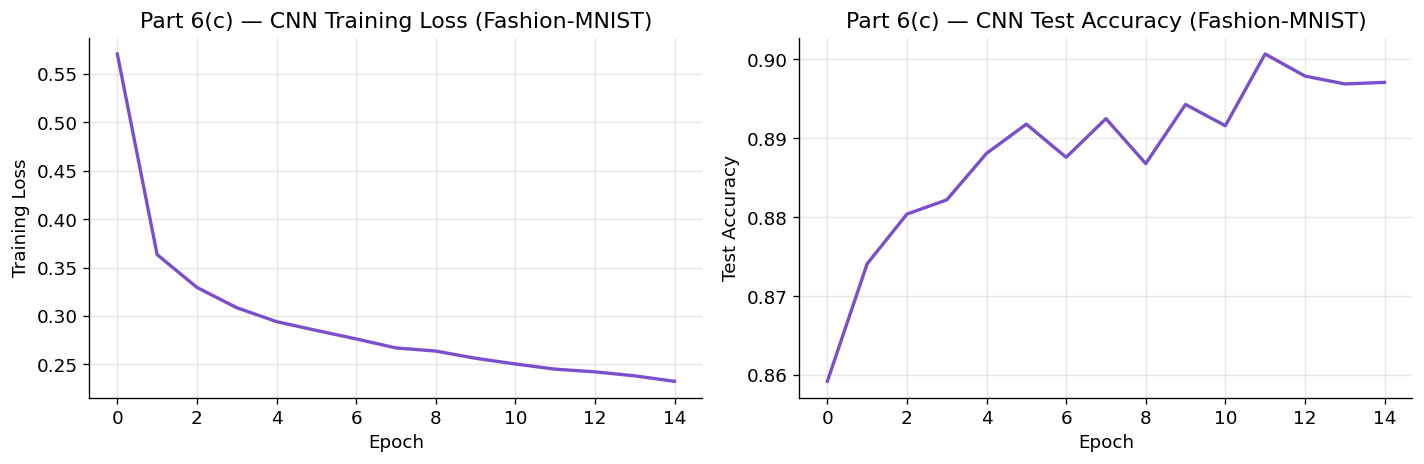


Final CNN test accuracy: 0.8971


In [68]:
class SimpleCNN:
    """
    Two-layer CNN for 28x28 Fashion-MNIST images.
    Architecture:
        Conv(1,8,k=3,pad=1) -> ReLU -> MaxPool(2x2)     (N,8,14,14)
        Conv(8,16,k=3,pad=1) -> ReLU -> MaxPool(2x2)    (N,16,7,7)
        Flatten -> FC(784, 10) -> Softmax
    Note: 16*7*7 = 784, same as input dim — coincidence but convenient.
    """
    def __init__(self, seed=0):
        np.random.seed(seed)
        self.W1 = he_init(1*3*3, 8).reshape(8,1,3,3);  self.b1 = np.zeros(8)
        self.W2 = he_init(8*3*3, 16).reshape(16,8,3,3); self.b2 = np.zeros(16)
        self.W3 = he_init(784, 10);   self.b3 = np.zeros((1, 10))
        self.cache = {}

    def forward(self, X, training=True):
        """X shape: (N, 1, 28, 28)"""
        c1,Xp1 = conv_forward(X, self.W1, self.b1, padding=1)
        a1 = relu(c1); p1, mk1 = maxpool_forward(a1)         # (N,8,14,14)
        c2,Xp2 = conv_forward(p1, self.W2, self.b2, padding=1)
        a2 = relu(c2); p2, mk2 = maxpool_forward(a2)         # (N,16,7,7)
        flat = p2.reshape(p2.shape[0], -1)                   # (N,784)
        out  = softmax(flat @ self.W3 + self.b3)
        self.cache = dict(X=X,c1=c1,a1=a1,p1=p1,mk1=mk1,Xp1=Xp1,
                          c2=c2,a2=a2,p2=p2,mk2=mk2,Xp2=Xp2,flat=flat,out=out)
        return out

    def backward(self, y_true):
        c = self.cache; N = y_true.shape[0]; g = {}
        dz3 = (c['out'] - y_true) / N
        g['dW3'] = c['flat'].T @ dz3; g['db3'] = dz3.sum(axis=0, keepdims=True)
        dp2 = (dz3 @ self.W3.T).reshape(c['p2'].shape)
        da2 = maxpool_backward(dp2, c['mk2'])
        dc2 = da2 * (c['c2'] > 0)
        dp1, g['dW2'], g['db2'] = conv_backward(dc2, c['Xp2'], self.W2, padding=1)
        da1 = maxpool_backward(dp1, c['mk1'])
        dc1 = da1 * (c['c1'] > 0)
        _, g['dW1'], g['db1'] = conv_backward(dc1, c['Xp1'], self.W1, padding=1)
        return g

    def predict(self, X): return self.forward(X, training=False)

# ── Train CNN on real Fashion-MNIST (60k/10k split) ───────────────────────────
np.random.seed(GLOBAL_SEED)
X_tr6 = X_train_full.reshape(-1, 1, 28, 28)
X_te6 = X_test_full.reshape(-1, 1, 28, 28)
def oh10(y): o=np.zeros((len(y),10)); o[np.arange(len(y)),y]=1; return o
Y_tr6 = oh10(y_train_full); y_te6 = y_test_full

cnn = SimpleCNN(seed=0)
opt6 = AdamOptimizer(lr=0.001)
CNN_EPOCHS=15; CNN_BATCH=128
cnn_losses, cnn_accs = [], []

for epoch in range(1, CNN_EPOCHS+1):
    epoch_loss=0.0; N=X_tr6.shape[0]
    idx=np.random.permutation(N)
    for start in range(0, N, CNN_BATCH):
        sl=idx[start:start+CNN_BATCH]
        Xb,Yb=X_tr6[sl],Y_tr6[sl]
        yh=cnn.forward(Xb); loss=cross_entropy_loss(yh,Yb)
        grads=cnn.backward(Yb)
        opt6.t+=1
        for key in ['W1','b1','W2','b2','W3','b3']:
            g=grads[f'd{key}']
            if key not in opt6.m: opt6.m[key]=np.zeros_like(g); opt6.v[key]=np.zeros_like(g)
            opt6.m[key]=opt6.beta1*opt6.m[key]+(1-opt6.beta1)*g
            opt6.v[key]=opt6.beta2*opt6.v[key]+(1-opt6.beta2)*g**2
            mh=opt6.m[key]/(1-opt6.beta1**opt6.t); vh=opt6.v[key]/(1-opt6.beta2**opt6.t)
            getattr(cnn,key)[:]  -= opt6.lr*mh/(np.sqrt(vh)+opt6.eps)
        epoch_loss+=loss*len(Xb)/N
    acc=accuracy(cnn.predict(X_te6),y_te6)
    cnn_losses.append(epoch_loss); cnn_accs.append(acc)
    print(f"  Epoch {epoch:2d} | loss={epoch_loss:.4f} | test_acc={acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_losses, color='#7b4fcc', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training Loss')
axes[0].set_title('Part 6(c) — CNN Training Loss (Fashion-MNIST)')
axes[1].plot(cnn_accs, color='#7b4fcc', lw=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Part 6(c) — CNN Test Accuracy (Fashion-MNIST)')
plt.tight_layout(); plt.show()
print(f"\nFinal CNN test accuracy: {cnn_accs[-1]:.4f}")


cnn.W1.size=72 + cnn.b1.size=8 + cnn.W2.size=1152 + cnn.b2.size=16 + cnn.W3.size=7840 + cnn.b3.size=10
CNN  params: 9,098
  = Conv1: 72+8  Conv2: 1152+16  FC: 7840+10
MLP  [784->256->128->10] params: 235,146
Ratio: MLP/CNN = 25.8x more parameters


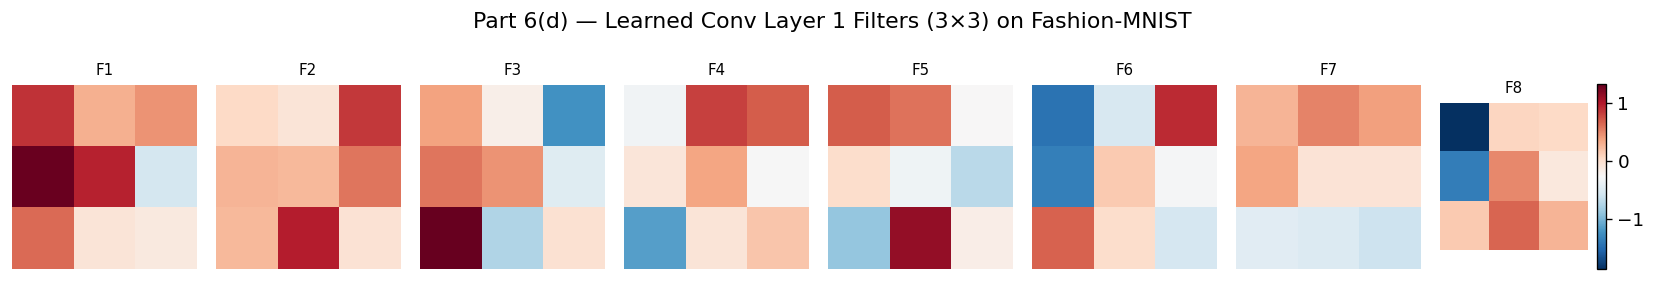

In [71]:
# ── Parameter count & filter visualization ────────────────────────────────────
cnn_params = cnn.W1.size+cnn.b1.size+cnn.W2.size+cnn.b2.size+cnn.W3.size+cnn.b3.size
mlp_params = (784*256+256)+(256*128+128)+(128*10+10)
print(f"{cnn.W1.size=} + {cnn.b1.size=} + {cnn.W2.size=} + {cnn.b2.size=} + {cnn.W3.size=} + {cnn.b3.size=}")
print(f"CNN  params: {cnn_params:,}")
print(f"  = Conv1: {cnn.W1.size}+{cnn.b1.size}  Conv2: {cnn.W2.size}+{cnn.b2.size}  FC: {cnn.W3.size}+{cnn.b3.size}")
print(f"MLP  [784->256->128->10] params: {mlp_params:,}")
print(f"Ratio: MLP/CNN = {mlp_params/cnn_params:.1f}x more parameters")

# Filter visualization
filters = cnn.W1[:, 0, :, :]   # (8, 3, 3)
vmin, vmax = filters.min(), filters.max()
fig, axes = plt.subplots(1, 8, figsize=(14, 2.2))
for i, ax in enumerate(axes):
    im = ax.imshow(filters[i], cmap='RdBu_r', vmin=vmin, vmax=vmax, interpolation='nearest')
    ax.set_title(f'F{i+1}', fontsize=9); ax.axis('off')
plt.suptitle('Part 6(d) — Learned Conv Layer 1 Filters (3×3) on Fashion-MNIST', y=1.05)
plt.colorbar(im, ax=axes[-1], fraction=0.15)
plt.tight_layout(); plt.show()


### ✏️ Part 6(d) — Analysis (3 pts)

**(i) Parameter count:** Show your calculation. Which has more? Which performs better on Fashion-MNIST?

**ANSWER: The MLP has 235,146 parameters, calculated as (784*256+256)+(256*128+128)+(128*10+10). The CNN has only 9,098 parameters, calculated as (8*1*3*3 + 8) + (16*8*3*3 + 16) + (784*10 + 10). The MLP has way more (25.8x as many) parameters, but the CNN still performs significantly better for this dataset.**

**(ii) Filter visualization:** What patterns do the learned filters detect?

**ANSWER: The filters learned by the CNN work as low-level feature detectors. Some of the filters detect horizontal/vertical edges (like F3, F6, or F8) and others detect other small things like corners or isolated pixels. The model then uses these tiny features and builds a "skeleton" of the features of the image.**

**(iii) Translation equivariance:** Describe an experiment to verify this property.

**ANSWER: To verify translation equivariance, you could run an image through a convolution layer to get a feature map, and then shift the original image by two pixels and pass it through again. If the property is correct, the second feature map should be exactly the same as the first, just shifted two pixels.**

**(iv) Pooling purpose:** Why is max pooling useful for classification? When would you avoid it?

**ANSWER: Max pooling is useful because it downsamples the calculated feature maps, reducing the required computation, and letting the model be a bit more resistant to small changes/translations. You would want to avoid max pooling if you needed your model to have high precision in the image, where the exact pixel location matters.**


---
# BONUS: Ablation Study — Putting It All Together (15 points)

> **Optional.** Attempt only after completing all 6 parts.

| Run | Config             | Init     | BN  | Dropout | L2    |
|-----|--------------------|----------|-----|---------|-------|
| 1   | Broken Baseline    | Standard | No  | No      | No    |
| 2   | + He Init          | He       | No  | No      | No    |
| 3   | + BN only          | He       | Yes | No      | No    |
| 4   | + Dropout (0.3)    | He       | No  | 0.3     | No    |
| 5   | + L2 (0.001)       | He       | No  | No      | 0.001 |
| 6   | + Init + BN        | He       | Yes | No      | No    |
| 7   | + Init + BN + Drop | He       | Yes | 0.3     | No    |
| 8   | Full Stack         | He       | Yes | 0.3     | 0.001 |

**Architecture:** `[784, 256, 128, 64, 10]`  **Optimizer:** Adam  **Epochs:** 20  **Batch:** 128  
**Data:** Full 10-class Fashion-MNIST (real 60k/10k split)


In [82]:
ablation_configs = [
    ('Broken Baseline', 'standard', False, 0.0,  0.0),
    ('+ He Init',       'he',       False, 0.0,  0.0),
    ('+ BN only',       'he',       True,  0.0,  0.0),
    ('+ Dropout(0.3)',  'he',       False, 0.3,  0.0),
    ('+ L2(0.001)',     'he',       False, 0.0,  0.001),
    ('+ Init + BN',     'he',       True,  0.0,  0.0),
    ('+ BN + Drop',     'he',       True,  0.3,  0.0),
    ('Full Stack',      'he',       True,  0.3,  0.001),
]

BONUS_EPOCHS=20; BONUS_BATCH=128; BONUS_DIMS=[784,256,128,64,10]; TARGET_ACC=0.85
ablation_results = {}

# Use the real Fashion-MNIST 60k/10k split
def oh10(y): o=np.zeros((len(y),10)); o[np.arange(len(y)),y]=1; return o
X_trb=X_train_full; Y_trb=oh10(y_train_full)
X_teb=X_test_full;  y_teb=y_test_full

for name, init, use_bn, dp, l2 in ablation_configs:
    np.random.seed(GLOBAL_SEED)
    net = DeepMLPwithBN(BONUS_DIMS,seed=0) if use_bn else DeepMLP(BONUS_DIMS,init=init,seed=0)
    opt = AdamOptimizer(lr=0.001)
    losses, accs, epoch_to_target = [], [], None

    for epoch in range(1, BONUS_EPOCHS+1):
        N=X_trb.shape[0]; epoch_loss=0.0
        for Xb,Yb in get_minibatches(X_trb,Y_trb,BONUS_BATCH,seed=epoch):
            if use_bn:
                yh=net.forward(Xb,training=True); grads=net.backward(Yb)
                net.update_params(grads,opt)
            else:
                yh=net.forward(Xb,training=True,dropout_p=dp)
                loss=cross_entropy_loss(yh,Yb)
                if l2>0:
                    for ll in range(1,net.L+1): loss+=0.5*l2*np.sum(net.params[f'W{ll}']**2)
                grads=net.backward(Yb,l2_lambda=l2,dropout_p=dp)
                opt.update(net.params,grads,net.layer_dims)
            epoch_loss+=cross_entropy_loss(yh,Yb)*len(Xb)/N
        acc=accuracy(net.predict(X_teb),y_teb)
        losses.append(epoch_loss); accs.append(acc)
        if epoch_to_target is None and acc>=TARGET_ACC: epoch_to_target=epoch

    ablation_results[name]={
        'losses':losses,'accs':accs,'final_acc':accs[-1],
        'epoch_to_target': epoch_to_target if epoch_to_target else 'not reached'
    }
    print(f"  {name:<22} | acc={accs[-1]:.4f} | epochs_to_{int(TARGET_ACC*100)}%: {ablation_results[name]['epoch_to_target']}")


  Broken Baseline        | acc=0.8260 | epochs_to_85%: not reached
  + He Init              | acc=0.8915 | epochs_to_85%: 2
  + BN only              | acc=0.8907 | epochs_to_85%: 1
  + Dropout(0.3)         | acc=0.8875 | epochs_to_85%: 3
  + L2(0.001)            | acc=0.8836 | epochs_to_85%: 2
  + Init + BN            | acc=0.8907 | epochs_to_85%: 1
  + BN + Drop            | acc=0.8907 | epochs_to_85%: 1
  Full Stack             | acc=0.8907 | epochs_to_85%: 1


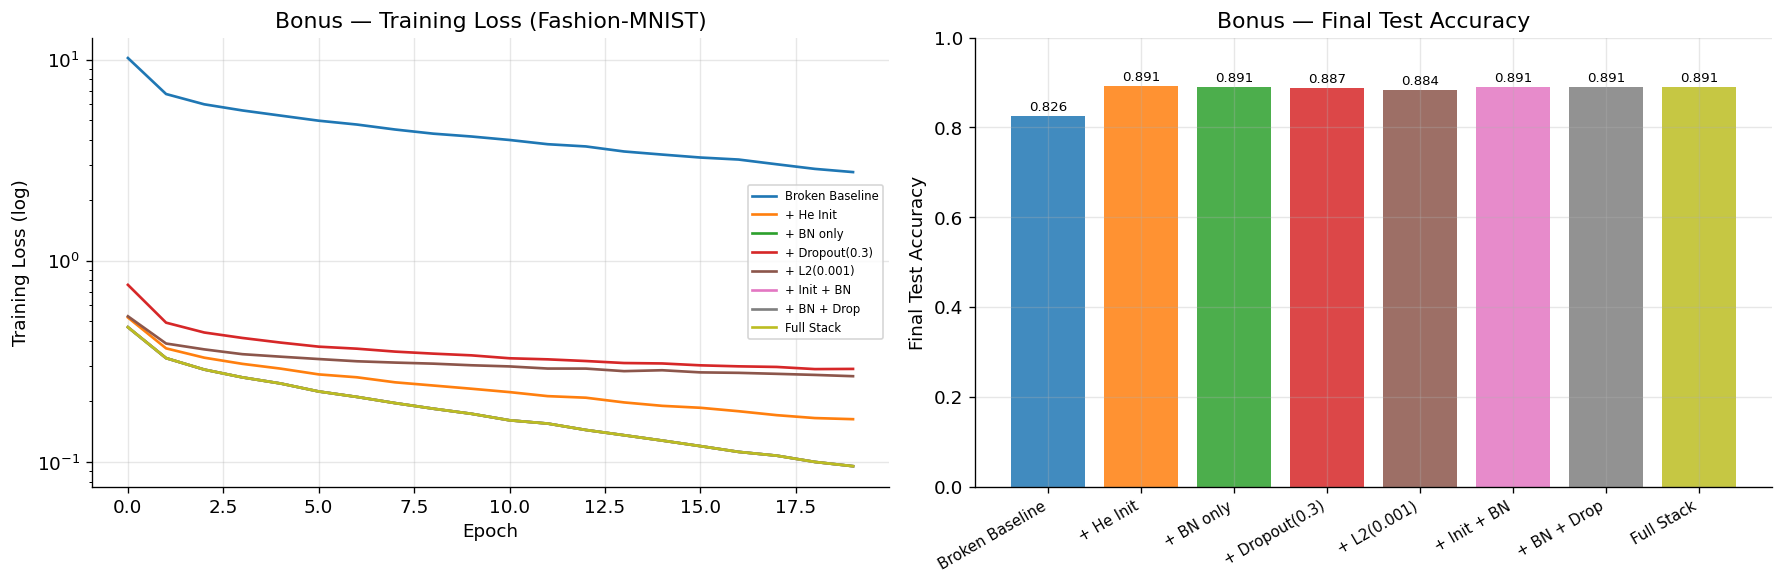


Config                 |  Final Acc |  Epochs to 85%
----------------------------------------------------
Broken Baseline        |     0.8260 |    not reached
+ He Init              |     0.8915 |              2
+ BN only              |     0.8907 |              1
+ Dropout(0.3)         |     0.8875 |              3
+ L2(0.001)            |     0.8836 |              2
+ Init + BN            |     0.8907 |              1
+ BN + Drop            |     0.8907 |              1
Full Stack             |     0.8907 |              1


In [83]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cmap = plt.cm.tab10
for i, (name,*_) in enumerate(ablation_configs):
    col=cmap(i/len(ablation_configs)); r=ablation_results[name]
    axes[0].plot(r['losses'], label=name, color=col, lw=1.6)
    axes[1].bar(i, r['final_acc'], color=col, alpha=0.85)

axes[0].set_yscale('log'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss (log)'); axes[0].set_title('Bonus — Training Loss (Fashion-MNIST)')
axes[0].legend(fontsize=7)
axes[1].set_xticks(range(len(ablation_configs)))
axes[1].set_xticklabels([n for n,*_ in ablation_configs], rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Final Test Accuracy'); axes[1].set_ylim(0, 1.0)
axes[1].set_title('Bonus — Final Test Accuracy')
for i,(name,*_) in enumerate(ablation_configs):
    acc=ablation_results[name]['final_acc']
    axes[1].text(i, acc+0.005, f'{acc:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

print(f"\n{'Config':<22} | {'Final Acc':>10} | {'Epochs to 85%':>14}")
print("-"*52)
for name,*_ in ablation_configs:
    r=ablation_results[name]
    print(f"{name:<22} | {r['final_acc']:>10.4f} | {str(r['epoch_to_target']):>14}")


### ✏️ Bonus — Written Analysis (4 pts)

**(i) Single biggest win:** Which component gave the largest single improvement over the broken baseline?

**ANSWER: 

**(ii) Interaction effects:** Is Run 6 (Init+BN) better than the sum of Runs 2+3 improvements?

**ANSWER: 

**(iii) Diminishing returns:** At what point do additional components stop providing meaningful gains?

**ANSWER: 

**(iv) Practical recommendation:** If constrained to only two components, which would you pick?

**ANSWER: 
